In [219]:
cd e:\Box\One Drive To Box Migration\Immunotherapy_databases\Italy\ML\git_project

e:\Box\One Drive To Box Migration\Immunotherapy_databases\Italy\ML\git_project


In [220]:
# Import modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, chi2_contingency
from lifelines import CoxPHFitter

In [221]:
# Read in csv with data

df=pd.read_csv(r"E:\OneDrive - Imperial College London\Immunotherapy_databases\Italy\2024_Jun_14_AtezoBev_DB_Full.csv",encoding='latin1')

In [222]:
# Assign 1 and 2 year mortality and PFS

from numpy import nan

df["One_Year_Mort"] = nan

df["One_Year_Mort"] = np.where(((df["DEAD"]==1) & (df["OS (months)"]<12)),1,df["One_Year_Mort"])
df["One_Year_Mort"] = np.where(((df["DEAD"]==1) & (df["OS (months)"]>=12)),0,df["One_Year_Mort"])
df["One_Year_Mort"] = np.where(((df["DEAD"]==0) & (df["OS (months)"]>=9)),0,df["One_Year_Mort"])
print(df["One_Year_Mort"].value_counts())
print(df["One_Year_Mort"].isnull().sum())


df["Two_Year_Mort"] = nan
df["Two_Year_Mort"] = np.where(((df["DEAD"]==1) & (df["OS (months)"]<24)),1,df["Two_Year_Mort"])
df["Two_Year_Mort"] = np.where(((df["DEAD"]==1) & (df["OS (months)"]>=24)),0,df["Two_Year_Mort"])
df["Two_Year_Mort"] = np.where(((df["DEAD"]==0) & (df["OS (months)"]>=21)),0,df["Two_Year_Mort"])

print(df["Two_Year_Mort"].value_counts())
print(df["Two_Year_Mort"].isnull().sum())


df["One_Year_Progression"] = nan
df["One_Year_Progression"] = np.where(((df["Progression"]==1) & (df["PFS (months)"]<12)),1,df["One_Year_Progression"])
df["One_Year_Progression"] = np.where(((df["Progression"]==1) & (df["PFS (months)"]>=12)),0,df["One_Year_Progression"])
df["One_Year_Progression"] = np.where(((df["Progression"]==0) & (df["PFS (months)"]>=9)),0,df["One_Year_Progression"])

print(df["One_Year_Progression"].value_counts())
print(df["One_Year_Progression"].isnull().sum())


df["Two_Year_Progression"] = nan
df["Two_Year_Progression"] = np.where(((df["Progression"]==1) & (df["PFS (months)"]<24)),1,df["Two_Year_Progression"])
df["Two_Year_Progression"] = np.where(((df["Progression"]==1) & (df["PFS (months)"]>=24)),0,df["Two_Year_Progression"])
df["Two_Year_Progression"] = np.where(((df["Progression"]==0) & (df["PFS (months)"]>=21)),0,df["Two_Year_Progression"])

print(df["Two_Year_Progression"].value_counts())
print(df["Two_Year_Progression"].isnull().sum())


df["One_Year_Progression_death"] = nan
df["One_Year_Progression_death"] = np.where(((df["Progression_death"]==1) & (df["PFS_OS"]<12)),1,df["One_Year_Progression_death"])
df["One_Year_Progression_death"] = np.where(((df["Progression_death"]==1) & (df["PFS_OS"]>=12)),0,df["One_Year_Progression_death"])
df["One_Year_Progression_death"] = np.where(((df["Progression_death"]==0) & (df["PFS_OS"]>=9)),0,df["One_Year_Progression_death"])

print(df["One_Year_Progression_death"].value_counts())
print(df["One_Year_Progression_death"].isnull().sum())


df["Six_Month_Progression_death"] = nan
df["Six_Month_Progression_death"] = np.where(((df["Progression_death"]==1) & (df["PFS_OS"]<6)),1,df["Six_Month_Progression_death"])
df["Six_Month_Progression_death"] = np.where(((df["Progression_death"]==1) & (df["PFS_OS"]>=6)),0,df["Six_Month_Progression_death"])
df["Six_Month_Progression_death"] = np.where(((df["Progression_death"]==0) & (df["PFS_OS"]>=3)),0,df["Six_Month_Progression_death"])

print(df["Six_Month_Progression_death"].value_counts())
print(df["Six_Month_Progression_death"].isnull().sum())

One_Year_Mort
0.0    336
1.0    296
Name: count, dtype: int64
303
Two_Year_Mort
1.0    379
0.0     62
Name: count, dtype: int64
494
One_Year_Progression
1.0    444
0.0    178
Name: count, dtype: int64
313
Two_Year_Progression
1.0    490
0.0     27
Name: count, dtype: int64
418
One_Year_Progression_death
1.0    520
0.0    173
Name: count, dtype: int64
242
Six_Month_Progression_death
1.0    405
0.0    378
Name: count, dtype: int64
152


In [223]:
# Define baseline clinical variables

baseline_variables = ["Age at Atezo/BevStart","Weight (Kg)","Height (Mt)","Sex","Cirrhosis 01","HBV 01","HCV 01","EtOH","NASH","AFP",
                      "Ascites at Atezo/Bev start 01","Encephalopathy at Atezo/Bev start","Child-Pugh Class",
                      "Presence of esophageal varices 01","MTD(cm)","Number of nodules","PVT 01","ECOG PS baseline","BCLC STAGE","M (EXTRAHEP METS)","M_Lungs","M_Bone","M_LN","M_Adrenal","M_CNS","M_perit",
                      "ALT","ALP","Alb g/l","Bilirubin","INR","Sodium (Na+) mmol/L","WCC","Hb g/dL","Neuts","Lympho", "Creatinine",
                      "PLT","CRP (mg/L)","Previous_surgery","Previous_RFA","Previous_TACE","Previous_TARE","Previous_EBRT"]

In [224]:
# Drop any cases where OS within 12 months is missing

df.dropna(subset=["One_Year_Mort"], inplace=True)

In [177]:
# Show counts for each continent

df["Continent"].value_counts()

Continent
Asia             268
Europe           233
North America    130
Name: count, dtype: int64

In [180]:
# Create a separate dataframe for missing variables correction

df_missing = df

baseline_variables_missing = baseline_variables

In [181]:
# Remove variables where more than 25% of values are missing

for b in baseline_variables:
    a = df[[b]].isnull().sum()
    print(b, a)
    if df[b].isnull().sum() > len(df)*0.25:
        df_missing.drop(b, axis=1, inplace=True)
        baseline_variables_missing.remove(b)

Age at Atezo/BevStart Age at Atezo/BevStart    3
dtype: int64
Weight (Kg) Weight (Kg)    21
dtype: int64
Height (Mt) Height (Mt)    40
dtype: int64
Sex Sex    0
dtype: int64
Cirrhosis 01 Cirrhosis 01    3
dtype: int64
HBV 01 HBV 01    0
dtype: int64
HCV 01 HCV 01    0
dtype: int64
EtOH EtOH    1
dtype: int64
NASH NASH    0
dtype: int64
AFP AFP    13
dtype: int64
Ascites at Atezo/Bev start 01 Ascites at Atezo/Bev start 01    23
dtype: int64
Encephalopathy at Atezo/Bev start Encephalopathy at Atezo/Bev start    23
dtype: int64
Child-Pugh Class Child-Pugh Class    7
dtype: int64
Presence of esophageal varices 01 Presence of esophageal varices 01    378
dtype: int64
Number of nodules Number of nodules    19
dtype: int64
PVT 01 PVT 01    52
dtype: int64
ECOG PS baseline ECOG PS baseline    4
dtype: int64
BCLC STAGE BCLC STAGE    3
dtype: int64
M (EXTRAHEP METS) M (EXTRAHEP METS)    3
dtype: int64
M_Lungs M_Lungs    41
dtype: int64
M_Bone M_Bone    41
dtype: int64
M_LN M_LN    42
dtype: int6

In [182]:
# List remaining variables after removal of missing variables

baseline_variables_missing

['Age at Atezo/BevStart',
 'Weight (Kg)',
 'Height (Mt)',
 'Sex',
 'Cirrhosis 01',
 'HBV 01',
 'HCV 01',
 'EtOH',
 'NASH',
 'AFP',
 'Ascites at Atezo/Bev start 01',
 'Encephalopathy at Atezo/Bev start',
 'Child-Pugh Class',
 'MTD(cm)',
 'Number of nodules',
 'PVT 01',
 'ECOG PS baseline',
 'BCLC STAGE',
 'M (EXTRAHEP METS)',
 'M_Lungs',
 'M_Bone',
 'M_LN',
 'M_Adrenal',
 'M_CNS',
 'M_perit',
 'ALT',
 'ALP',
 'Alb g/l',
 'Bilirubin',
 'Sodium (Na+) mmol/L',
 'WCC',
 'Hb g/dL',
 'Neuts',
 'Lympho',
 'PLT',
 'Previous_surgery',
 'Previous_RFA',
 'Previous_TACE',
 'Previous_TARE',
 'Previous_EBRT']

In [184]:
# Show the number of missing variables for each retained variable

for b in baseline_variables_missing:
    a = df_missing[[b]].isnull().sum()
    print(b, a)

Age at Atezo/BevStart Age at Atezo/BevStart    3
dtype: int64
Weight (Kg) Weight (Kg)    21
dtype: int64
Height (Mt) Height (Mt)    40
dtype: int64
Sex Sex    0
dtype: int64
Cirrhosis 01 Cirrhosis 01    3
dtype: int64
HBV 01 HBV 01    0
dtype: int64
HCV 01 HCV 01    0
dtype: int64
EtOH EtOH    1
dtype: int64
NASH NASH    0
dtype: int64
AFP AFP    13
dtype: int64
Ascites at Atezo/Bev start 01 Ascites at Atezo/Bev start 01    23
dtype: int64
Encephalopathy at Atezo/Bev start Encephalopathy at Atezo/Bev start    23
dtype: int64
Child-Pugh Class Child-Pugh Class    7
dtype: int64
MTD(cm) MTD(cm)    35
dtype: int64
Number of nodules Number of nodules    19
dtype: int64
PVT 01 PVT 01    52
dtype: int64
ECOG PS baseline ECOG PS baseline    4
dtype: int64
BCLC STAGE BCLC STAGE    3
dtype: int64
M (EXTRAHEP METS) M (EXTRAHEP METS)    3
dtype: int64
M_Lungs M_Lungs    41
dtype: int64
M_Bone M_Bone    41
dtype: int64
M_LN M_LN    42
dtype: int64
M_Adrenal M_Adrenal    42
dtype: int64
M_CNS M_CNS 

In [185]:
# Show final number of all variables

print(len(baseline_variables_missing))
baseline_variables_missing

40


['Age at Atezo/BevStart',
 'Weight (Kg)',
 'Height (Mt)',
 'Sex',
 'Cirrhosis 01',
 'HBV 01',
 'HCV 01',
 'EtOH',
 'NASH',
 'AFP',
 'Ascites at Atezo/Bev start 01',
 'Encephalopathy at Atezo/Bev start',
 'Child-Pugh Class',
 'MTD(cm)',
 'Number of nodules',
 'PVT 01',
 'ECOG PS baseline',
 'BCLC STAGE',
 'M (EXTRAHEP METS)',
 'M_Lungs',
 'M_Bone',
 'M_LN',
 'M_Adrenal',
 'M_CNS',
 'M_perit',
 'ALT',
 'ALP',
 'Alb g/l',
 'Bilirubin',
 'Sodium (Na+) mmol/L',
 'WCC',
 'Hb g/dL',
 'Neuts',
 'Lympho',
 'PLT',
 'Previous_surgery',
 'Previous_RFA',
 'Previous_TACE',
 'Previous_TARE',
 'Previous_EBRT']

In [186]:
# drop child pugh class c cases, ECOG stage 3 and BCLC stage 4

df_missing = df_missing[df_missing["Child-Pugh Class"]!="C"]
df_missing = df_missing[df_missing["ECOG PS baseline"]!=3]
df_missing = df_missing[df_missing["BCLC STAGE"]!=4]


# Replaceme Child-Pugh with numerical values

df_missing["Child-Pugh Class"].replace({"A":1,"B":2}, inplace=True)

In [187]:
# For previous treatments and mets replace NaN with 0 - clinical imputation

baseline_met_tx = [
'M (EXTRAHEP METS)',
'M_Lungs',
'M_Bone',
'M_LN',
'M_Adrenal',
'M_CNS',
'M_perit',
'Previous_surgery',
'Previous_RFA',
'Previous_TACE',
'Previous_TARE',
'Previous_EBRT']

for b in baseline_met_tx:
    df_missing[b].fillna(0, inplace=True)

In [188]:
# Impute missing values using MICE

from src.data.preprocessing import mice_imputer

X_imputed = mice_imputer(df_missing[baseline_variables_missing],baseline_variables_missing)

In [189]:
# For categorical variables - round imputation estimate to 0 or 1

baseline_variables_missing_cat = [
'Sex',
'Cirrhosis 01',
'HBV 01',
'HCV 01',
'EtOH',
'NASH',
'Ascites at Atezo/Bev start 01',
'Encephalopathy at Atezo/Bev start',
'Child-Pugh Class',
'Number of nodules',
'PVT 01',
'ECOG PS baseline',
'BCLC STAGE',
'M (EXTRAHEP METS)',
'M_Lungs',
'M_Bone',
'M_LN',
'M_Adrenal',
'M_CNS',
'M_perit',
'Previous_surgery',
'Previous_RFA',
'Previous_TACE',
'Previous_TARE',
'Previous_EBRT']

X_imputed[baseline_variables_missing_cat] = np.round(X_imputed[baseline_variables_missing_cat],0)

In [190]:
# Copy the imputed database

df_2 = df_missing
df_2[baseline_variables_missing] = X_imputed[baseline_variables_missing]

In [191]:
# One hot encode multi-level categorical data

baseline_variables_missing_multicat = ["Child-Pugh Class","BCLC STAGE","ECOG PS baseline","Number of nodules"]

df_2[baseline_variables_missing_multicat]

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse=False)

one_hot_encoded = encoder.fit_transform(df_2[baseline_variables_missing_multicat])
df_enc = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(baseline_variables_missing_multicat), index=df_2.index)
df_enc.drop(columns=["Child-Pugh Class_2.0","Number of nodules_4.0","ECOG PS baseline_2.0","BCLC STAGE_3.0"], inplace=True)

df_2_enc = pd.concat([df_2["Continent"],df_2[baseline_variables_missing],df_enc, df_2["One_Year_Mort"]], axis=1)
df_2_enc.drop(columns=baseline_variables_missing_multicat, inplace=True)

df_2_enc["BMI"] = df_2_enc["Weight (Kg)"]/(df_2_enc["Height (Mt)"]**2)

df_2_enc.drop(columns=["Weight (Kg)","Height (Mt)"], inplace=True)

e:\Box\One Drive To Box Migration\Immunotherapy_databases\Italy\ML\git_project\.venv\lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [192]:
# Counts by continent

df_2_enc["Continent"].value_counts()

Continent
Asia             266
Europe           229
North America    126
Name: count, dtype: int64

In [193]:
# Assign Asia/North America for training/internal validation and Europe as test

df_2_enc["train"] = np.where(df_2_enc["Continent"] == "Europe",0,1)

df_2_enc["train"].value_counts()

train
1    393
0    229
Name: count, dtype: int64

In [194]:
# Save data to csv (calucate ALBI grade )

df_2_enc["albi"] = df_2_enc["Alb g/l"] * -0.0852 + np.log10(df_2_enc["Bilirubin"] * 0.66)

df_2_enc["albi_1"] = np.where(df_2_enc["albi"] <= -2.60, 1, 0)
df_2_enc["albi_2"] = np.where((df_2_enc["albi"] >-2.60) & (df_2_enc["albi"]<=-1.39), 1, 0)
df_2_enc["albi_3"] = np.where(df_2_enc["albi"] > -1.39, 1, 0)

#df_2_enc.to_csv(r"C:\Users\mat2k\OneDrive - Imperial College London\immunotherapy_databases\Italy\2024_Jun_25_Summary_Stats_correction.csv", index=False)

df_2_enc.drop(columns=["albi","albi_1","albi_2","albi_3"], inplace=True)

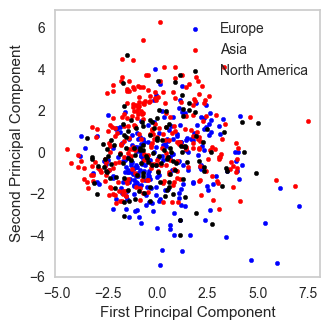

In [195]:
# PCA plot to visualise the data by continent

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Prepare the data
pca = PCA()
X_scaling = StandardScaler().fit_transform(df_2_enc.drop(columns=["One_Year_Mort", "Continent"]))
X_pca = pca.fit_transform(X_scaling)

# Create a figure
mm_inch = 1/25.4
figure = plt.figure(figsize=(88*mm_inch, 88*mm_inch))

# Define colors for each continent
colors = {"Europe": "blue", "Asia": "red", "North America": "black"}

# Plot each continent separately to allow for a legend
for continent, color in colors.items():
    idx = df_2_enc["Continent"].fillna("Asia") == continent
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], c=color, label=continent, s=10)

# Add labels and title
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.grid(None)

# Add a legend
plt.legend()

plt.tight_layout()

# Save figure
# plt.savefig(r"E:\OneDrive - Imperial College London\Immunotherapy_databases\Italy\ML\LDH\figures\pca.svg", dpi=300, format="svg")
# plt.savefig(r"E:\OneDrive - Imperial College London\Immunotherapy_databases\Italy\ML\LDH\figures\pca.pdf", dpi=300, format="pdf")

# Show the plot
plt.show()

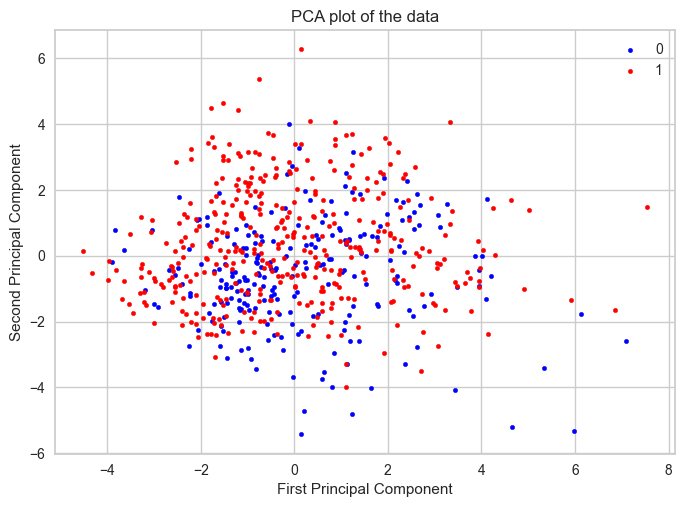

In [196]:
# PCA plot to visualise the data for train and test

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Prepare the data
pca = PCA()
X_scaling = StandardScaler().fit_transform(df_2_enc.drop(columns=["One_Year_Mort", "Continent"]))
X_pca = pca.fit_transform(X_scaling)

# Create a figure
fig = plt.figure()

# Define colors for each continent
colors = {0: "blue", 1: "red"}

# Plot each continent separately to allow for a legend
for train, color in colors.items():
    idx = df_2_enc["train"] == train
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], c=color, label=train, s=10)

# Add labels and title
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA plot of the data')

# Add a legend
plt.legend()

# Show the plot
plt.show()

In [197]:
# Make X_train and X_test cohorts based on continent stratification (training - Asia/North America, test - Europe)

df_2_enc.drop(columns=["train"], inplace=True)

df_test = df_2_enc[df_2_enc["Continent"] == "Europe"]
df_train = df_2_enc[df_2_enc["Continent"] != "Europe"]

X_train = df_train.drop(columns=["One_Year_Mort","Continent"], axis=1)
y_train = df_train["One_Year_Mort"]

X_test = df_test.drop(columns=["One_Year_Mort","Continent"], axis=1)
y_test = df_test["One_Year_Mort"]

print(len(X_train))
print(len(X_test))

393
229


In [198]:
# Create ALBI variable

df_2_enc["albi"] = df_2_enc["Alb g/l"] * -0.0852 + np.log10(df_2_enc["Bilirubin"] * 0.66)

df_2_enc["albi_1"] = np.where(df_2_enc["albi"] <= -2.60, 1, 0)
df_2_enc["albi_2"] = np.where((df_2_enc["albi"] >-2.60) & (df_2_enc["albi"]<=-1.39), 1, 0)
df_2_enc["albi_3"] = np.where(df_2_enc["albi"] > -1.39, 1, 0)
df_2_enc["AFP_400"] = np.where(df_2_enc["AFP"] > 400, 1, 0)

In [199]:
# Define continous and categorical variables for Table 1

table_1_list = ['Age at Atezo/BevStart',"Sex",'NASH','EtOH','HBV 01','HCV 01','Ascites at Atezo/Bev start 01','Encephalopathy at Atezo/Bev start','Child-Pugh Class_1.0',"MTD(cm)",'PVT 01','AFP_400','albi_1','albi_2','albi_3','M (EXTRAHEP METS)','ECOG PS baseline_0.0','ECOG PS baseline_1.0','BCLC STAGE_1.0','BCLC STAGE_2.0','Previous_surgery','Previous_RFA','Previous_TACE','Previous_TARE','Previous_EBRT']

table_1_list_cont = ['Age at Atezo/BevStart','MTD(cm)']

table_1_list_cat = ["Sex",'NASH','EtOH','HBV 01','HCV 01','Ascites at Atezo/Bev start 01','Encephalopathy at Atezo/Bev start','Child-Pugh Class_1.0','PVT 01','AFP_400','albi_1','albi_2','albi_3','M (EXTRAHEP METS)','ECOG PS baseline_0.0','ECOG PS baseline_1.0','BCLC STAGE_1.0','BCLC STAGE_2.0','Previous_surgery','Previous_RFA','Previous_TACE','Previous_TARE','Previous_EBRT']

In [200]:
# Split the training cohort into training and internal validation

# import train_test_split

from sklearn.model_selection import train_test_split

X_train_mod, X_val_mod, y_train_mod, y_val_mod = train_test_split(X_train, y_train, test_size=0.3, random_state=42, stratify=y_train)

#Validation vs Training split

df_2_enc["validation"] = nan
df_2_enc["validation"].loc[X_val_mod.index] = 1
df_2_enc["validation"].loc[X_train_mod.index] = 0


# Test vs Validation split
df_2_enc["test"] = nan
df_2_enc["test"].loc[X_test.index] = 1
df_2_enc["test"].loc[X_val_mod.index] = 0

df_2_enc["validation"].value_counts()
df_2_enc["test"].value_counts()

C:\Users\mat2k\AppData\Local\Temp\ipykernel_6208\3301241770.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2_enc["validation"].loc[X_val_mod.index] = 1
C:\Users\mat2k\AppData\Local\Temp\ipykernel_6208\3301241770.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2_enc["validation"].loc[X_train_mod.index] = 0
C:\Users\mat2k\AppData\Local\Temp\ipykernel_6208\3301241770.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df

test
1.0    229
0.0    118
Name: count, dtype: int64

In [201]:
# Generate Table 1 with testing between variables - comparing training, validation and test

# from scipy.stats import chi2_contingency
# from scipy.stats import ttest_ind

variable = []
training = []
validation = []
test = []
train_val_p_value = []
val_test_p_value = []

for i in table_1_list:

    if i in table_1_list_cat:
        variable.append(i)
        training.append(f"{pd.crosstab(df_2_enc[i],df_2_enc['validation']).iloc[1,0]} ({np.round(100*pd.crosstab(df_2_enc[i],df_2_enc['validation'], normalize='columns').iloc[1,0],1)})")
        validation.append(f"{pd.crosstab(df_2_enc[i],df_2_enc['validation']).iloc[1,1]} ({np.round(100*pd.crosstab(df_2_enc[i],df_2_enc['validation'], normalize='columns').iloc[1,1],1)})")
        test.append(f"{pd.crosstab(df_2_enc[i],df_2_enc['test']).iloc[1,1]} ({np.round(100*pd.crosstab(df_2_enc[i],df_2_enc['test'], normalize='columns').iloc[1,1],1)})")
        train_val_p_value.append(np.round(chi2_contingency(pd.crosstab(df_2_enc[i],df_2_enc['validation']))[1],4))
        val_test_p_value.append(np.round(chi2_contingency(pd.crosstab(df_2_enc[i],df_2_enc['test']))[1],4))

    if i in table_1_list_cont:
        variable.append(i)
        training.append(f"{np.round(df_2_enc[i].loc[X_train_mod.index].mean(),1)} ({np.round(df_2_enc[i].loc[X_train_mod.index].std(),1)})")
        validation.append(f"{np.round(df_2_enc[i].loc[X_val_mod.index].mean(),1)} ({np.round(df_2_enc[i].loc[X_val_mod.index].std(),1)})")
        test.append(f"{np.round(df_2_enc[i].loc[X_test.index].mean(),1)} ({np.round(df_2_enc[i].loc[X_test.index].std(),1)})")
        train_val_p_value.append(np.round(ttest_ind(df_2_enc[i].loc[X_train_mod.index],df_2_enc[i].loc[X_val_mod.index])[1],4))
        val_test_p_value.append(np.round(ttest_ind(df_2_enc[i].loc[X_val_mod.index],df_2_enc[i].loc[X_test.index])[1],4))

table_1 = pd.DataFrame({"Variable":variable,"Training":training,"Validation":validation,"Train-Val P-value":train_val_p_value,"Test":test,"Val-Test P-value":val_test_p_value})

table_1

,Variable,Training,Validation,Train-Val P-value,Test,Val-Test P-value
0,Age at Atezo/BevStart,64.7 (10.9),65.5 (12.4),0.5607,67.4 (10.3),0.1137
1,Sex,221 (80.4),98 (83.1),0.6285,178 (77.7),0.3060
2,NASH,31 (11.3),10 (8.5),0.5145,40 (17.5),0.0359
3,EtOH,82 (29.8),36 (30.5),0.9866,56 (24.5),0.2792
4,HBV 01,123 (44.7),42 (35.6),0.1164,44 (19.2),0.0013
5,HCV 01,74 (26.9),42 (35.6),0.1075,71 (31.0),0.4573
6,Ascites at Atezo/Bev start 01,68 (24.7),19 (16.1),0.0792,69 (30.1),0.0066
7,Encephalopathy at Atezo/Bev start,8 (2.9),3 (2.5),1.0000,3 (1.3),0.6895
8,Child-Pugh Class_1.0,223 (81.1),100 (84.7),0.4689,182 (79.5),0.2953
9,MTD(cm),6.6 (4.3),7.2 (4.9),0.2802,5.9 (3.9),0.0072


In [202]:
# Scaler for X_train and X_test - continous variables

baseline_variables_missing_cont = [
'Age at Atezo/BevStart',
'BMI',
'AFP',
'MTD(cm)',
'ALT',
'ALP',
'Alb g/l',
'Bilirubin',
'WCC',
'Hb g/dL',
'Neuts',
'Lympho',
'PLT']

from src.model_builder.feature_selection import standardise_features

X_train_scale, X_test_scale = standardise_features(X_train, X_test, baseline_variables_missing_cont)



LASSO Features
Best param: {'C': 3.727593720314938}
43
Index(['Age at Atezo/BevStart', 'BMI', 'AFP', 'MTD(cm)', 'ALT', 'ALP',
       'Alb g/l', 'Bilirubin', 'WCC', 'Hb g/dL', 'Neuts', 'Lympho', 'PLT',
       'Sex', 'Cirrhosis 01', 'HBV 01', 'HCV 01', 'EtOH', 'NASH',
       'Ascites at Atezo/Bev start 01', 'Encephalopathy at Atezo/Bev start',
       'PVT 01', 'M (EXTRAHEP METS)', 'M_Lungs', 'M_Bone', 'M_LN', 'M_Adrenal',
       'M_perit', 'Sodium (Na+) mmol/L', 'Previous_surgery', 'Previous_RFA',
       'Previous_TACE', 'Previous_TARE', 'Previous_EBRT',
       'Child-Pugh Class_1.0', 'BCLC STAGE_1.0', 'BCLC STAGE_2.0',
       'ECOG PS baseline_0.0', 'ECOG PS baseline_1.0', 'Number of nodules_0.0',
       'Number of nodules_1.0', 'Number of nodules_2.0',
       'Number of nodules_3.0'],
      dtype='object')

Elastic Net Features
Best param: {'C': 0.08685113737513521, 'l1_ratio': 0.0}
43
Index(['Age at Atezo/BevStart', 'BMI', 'AFP', 'MTD(cm)', 'ALT', 'ALP',
       'Alb g/l', 'Bilirubin'

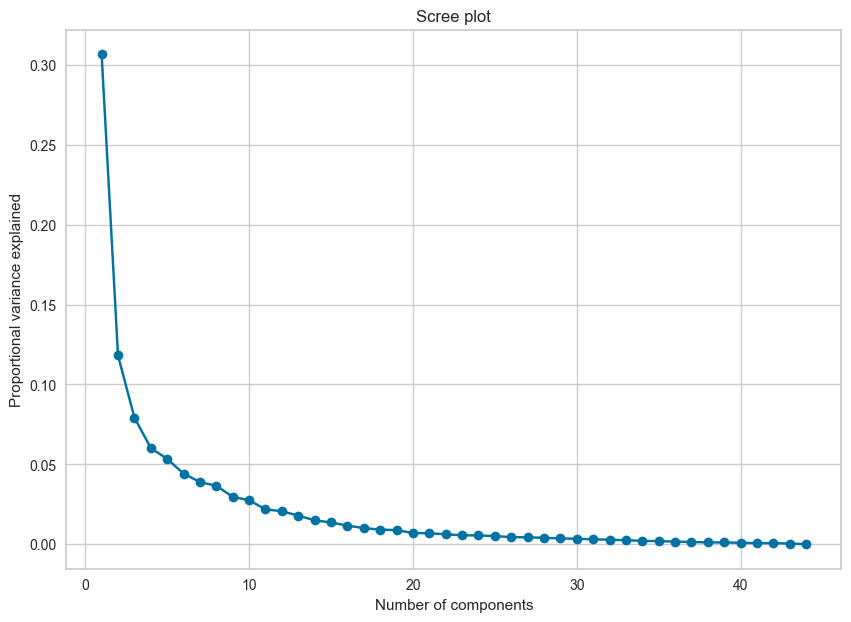


PCA Features
43
['Age at Atezo/BevStart' 'BMI' 'AFP' 'MTD(cm)' 'ALT' 'ALP' 'Alb g/l'
 'Bilirubin' 'WCC' 'Hb g/dL' 'Neuts' 'Lympho' 'PLT' 'Sex' 'Cirrhosis 01'
 'HBV 01' 'HCV 01' 'EtOH' 'NASH' 'Ascites at Atezo/Bev start 01'
 'Encephalopathy at Atezo/Bev start' 'PVT 01' 'M (EXTRAHEP METS)'
 'M_Lungs' 'M_Bone' 'M_LN' 'M_Adrenal' 'M_perit' 'Sodium (Na+) mmol/L'
 'Previous_surgery' 'Previous_RFA' 'Previous_TACE' 'Previous_TARE'
 'Previous_EBRT' 'Child-Pugh Class_1.0' 'BCLC STAGE_1.0' 'BCLC STAGE_2.0'
 'ECOG PS baseline_0.0' 'ECOG PS baseline_1.0' 'Number of nodules_0.0'
 'Number of nodules_1.0' 'Number of nodules_2.0' 'Number of nodules_3.0']

Boruta Features
9
['AFP', 'MTD(cm)', 'ALP', 'Alb g/l', 'Bilirubin', 'Hb g/dL', 'Lympho', 'PVT 01', 'Sodium (Na+) mmol/L']

Random Forest Features


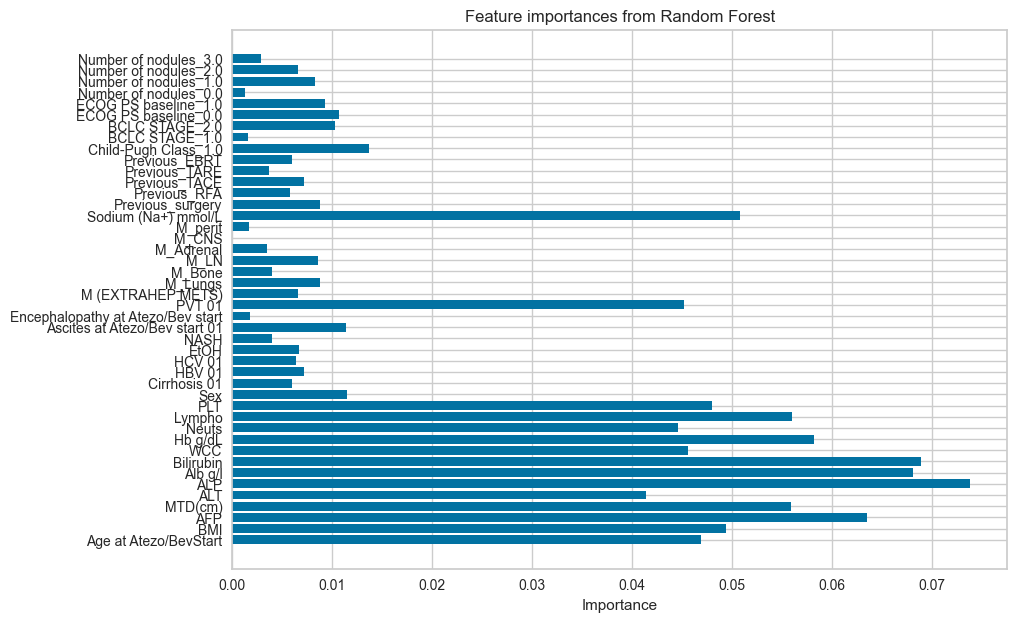


Random Forest Features
43
Index(['Age at Atezo/BevStart', 'BMI', 'AFP', 'MTD(cm)', 'ALT', 'ALP',
       'Alb g/l', 'Bilirubin', 'WCC', 'Hb g/dL', 'Neuts', 'Lympho', 'PLT',
       'Sex', 'Cirrhosis 01', 'HBV 01', 'HCV 01', 'EtOH', 'NASH',
       'Ascites at Atezo/Bev start 01', 'Encephalopathy at Atezo/Bev start',
       'PVT 01', 'M (EXTRAHEP METS)', 'M_Lungs', 'M_Bone', 'M_LN', 'M_Adrenal',
       'M_perit', 'Sodium (Na+) mmol/L', 'Previous_surgery', 'Previous_RFA',
       'Previous_TACE', 'Previous_TARE', 'Previous_EBRT',
       'Child-Pugh Class_1.0', 'BCLC STAGE_1.0', 'BCLC STAGE_2.0',
       'ECOG PS baseline_0.0', 'ECOG PS baseline_1.0', 'Number of nodules_0.0',
       'Number of nodules_1.0', 'Number of nodules_2.0',
       'Number of nodules_3.0'],
      dtype='object')

Mutual Information Features
10
Index(['ALT', 'ALP', 'Alb g/l', 'WCC', 'Hb g/dL', 'Lympho', 'PVT 01',
       'Previous_TACE', 'Number of nodules_0.0', 'Number of nodules_3.0'],
      dtype='object')

Pearson Fe

In [203]:
# Apply feature selection to baseline features

from src.model_builder.feature_selection import feature_selector

baseline_selected_features_dict = feature_selector(X_train_scale, y_train)

In [205]:
# Train machine learning algorithms with feature sets using clinical selected features

from src.model_builder.ml_prediction import ml_trainer

X_train_mod, X_val_mod, y_train_mod, y_val_mod = train_test_split(X_train_scale, y_train, test_size=0.3, random_state=42,stratify=y_train)

clinical_ml = ml_trainer()

clinical_ml.trainer(X_train_mod, y_train_mod, X_val_mod, y_val_mod, baseline_selected_features_dict)

print(clinical_ml.results)        

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

...

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

[{'feature_set': 'All', 'results': [{'model': 'Logistic Regression', 'best_parameters': {'C': 0.1, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'auto', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}, 'model_instance': GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=1, n_splits=10, random_state=42),
             estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10]},
             scoring=make_scorer(roc_auc_score, needs_proba=True)), 'roc_auc_train': 0.8608994311473651, 'roc_auc_val': 0.7999892669314157, 'roc_auc_test': 0.7089160839160839, 'f1_train': 0.7297297297297298, 'f1_val': 0.6968325791855204, 'f1_test': 0.5742574257425743, 'recall_train': 0.6694214876033058, 'recall_val': 0.6363636363636364, 'recall_test': 0.5576923076923077, 'precision_train': 0.801980198019802, 'preci

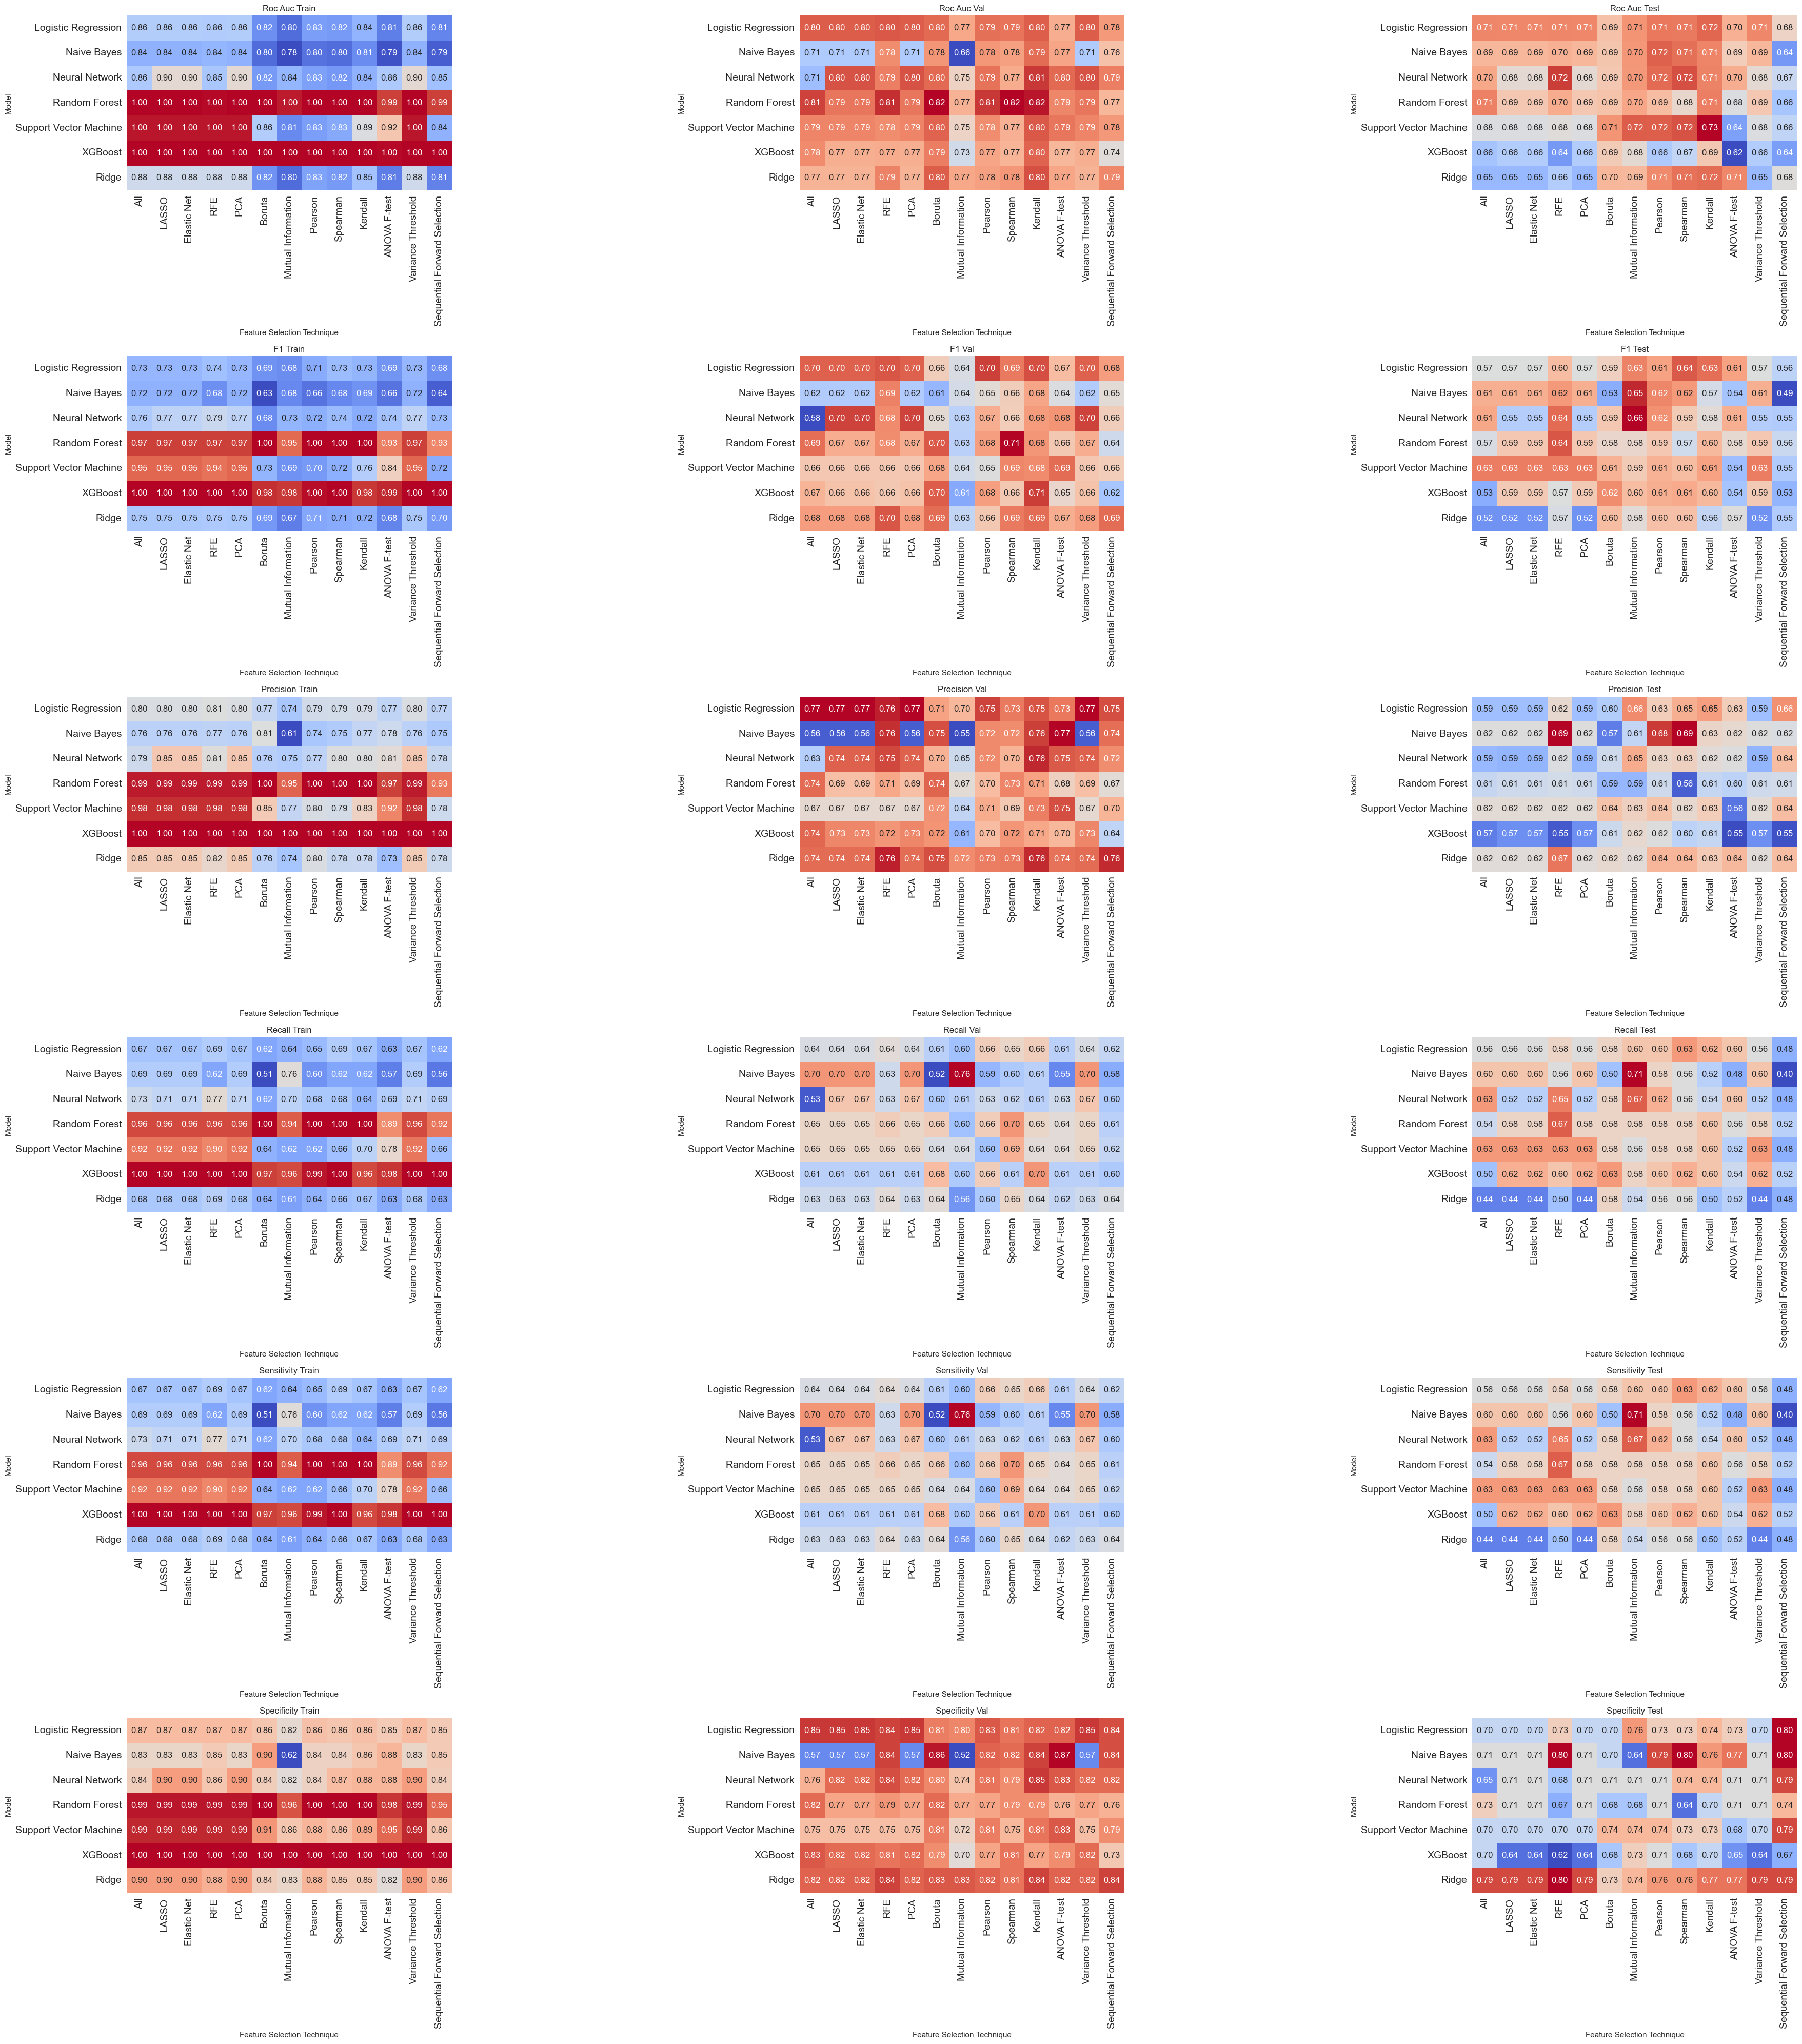

In [206]:
# Evaluate the results of the machine learning and feature selection models

from src.model_builder.ml_prediction import ml_evaluator

clinical_ml_eval = ml_evaluator(clinical_ml.results)

# Heatmap showing result of ML and feature selection predictions for 1-year OS

clinical_ml_eval.results_heatmap()

In [207]:
# Rank top 3 combinations based on internal validation performance

clinical_ml_eval.top_3_combinations(train_test_val_set="test")

Best model: Support Vector Machine with feature selection technique: Kendall, val_auc: 0.7319347319347319
Second best model: Neural Network with feature selection technique: RFE, val_auc: 0.7249417249417249
Third best model: Naive Bayes with feature selection technique: Pearson, val_auc: 0.717948717948718


In [208]:
# Ensemble top 3 combinations based on internal validation performance

ensemble_model_results = clinical_ml_eval.ensemble_top_3(X_train_mod, y_train_mod, X_val_mod, y_val_mod, baseline_selected_features_dict, train_test_val_set="test")

e:\Box\One Drive To Box Migration\Immunotherapy_databases\Italy\ML\git_project\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(



Model 1
('Support Vector Machine', 'Kendall')
[(0.8886980787807233, 0.8502477914242621, 0.923674835366512)]
[(0.7982719759579263, 0.7439817826935589, 0.8496013790131437)]
[(0.7319347319347319, 0.6425691244239631, 0.8125)]

Model 2
('Neural Network', 'RFE')
[(0.8541375979392508, 0.8071536306830425, 0.8972704189589504)]
[(0.7969840077278094, 0.7383899291230298, 0.8534501174962614)]
[(0.7249417249417249, 0.6258928571428573, 0.8103993105429474)]

Model 3
('Naive Bayes', 'Pearson')
[(0.8012772351615326, 0.7485352082667519, 0.8510841836734694)]
[(0.7824675324675325, 0.7213154492566258, 0.8355376344086022)]
[(0.717948717948718, 0.6120337995337995, 0.8090034965034965)]

Ensemble Model
[(0.8573575185145432, 0.80928, 0.9011553273427472)]
[(0.8035311795642374, 0.7515084153699586, 0.8535276073619632)]
[(0.7456293706293706, 0.6561771561771562, 0.83744557329463)]


In [209]:
# External validation cohort performance
from src.model_evaluation.model_metrics import compute_auc_ci

ensemble_model_results["ensemble_model"]["new_test_truth"] = y_test
ensemble_model_results["ensemble_model"]["new_test_proba"] = clinical_ml_eval.ensemble_model_new_predictor(X_test_scale)
ensemble_model_results["ensemble_model"]["new_test_auc"] = compute_auc_ci(y_test, ensemble_model_results["ensemble_model"]["new_test_proba"])

ensemble_model_results["ensemble_model"]["new_test_auc"]

(0.7509917607567896, 0.6883713804197947, 0.8161551381890365)

In [210]:
# Clinical benchmarking against know predictors

from src.model_builder.ml_prediction import custom_model_predictor

X_train['NLR'] = X_train['Neuts']/X_train['Lympho']
X_test['NLR'] = X_test['Neuts']/X_test['Lympho']

X_train_mod = X_train_mod.join(X_train['NLR'])
X_val_mod = X_val_mod.join(X_train['NLR'])
X_test_scale = X_test_scale.join(X_test['NLR'])

X_train['PLR'] = X_train['PLT']/X_train['Lympho']
X_test['PLR'] = X_test['PLT']/X_test['Lympho']

X_train_mod = X_train_mod.join(X_train['PLR'])
X_val_mod = X_val_mod.join(X_train['PLR'])
X_test_scale = X_test_scale.join(X_test['PLR'])

X_train["albi"] = X_train["Alb g/l"] * -0.0852 + np.log10(X_train["Bilirubin"] * 0.66)
X_test["albi"] = X_test["Alb g/l"] * -0.0852 + np.log10(X_test["Bilirubin"] * 0.66)

# if albi less than or equal to -2.60 then make X_test["albi_1"] = 1 else 0
X_train["albi_1"] = np.where(X_train["albi"] <= -2.60, 1, 0)
X_train["albi_2"] = np.where((X_train["albi"] >-2.60) & (X_train["albi"]<=-1.39), 1, 0)
X_train["albi_3"] = np.where(X_train["albi"] > -1.39, 1, 0)

X_test["albi_1"] = np.where(X_test["albi"] <= -2.60, 1, 0)
X_test["albi_2"] = np.where((X_test["albi"] >-2.60) & (X_test["albi"]<=-1.39), 1, 0)
X_test["albi_3"] = np.where(X_test["albi"] > -1.39, 1, 0)

X_train_mod = X_train_mod.join(X_train[["albi_1","albi_2","albi_3"]])
X_val_mod = X_val_mod.join(X_train[["albi_1","albi_2","albi_3"]])
X_test_scale = X_test_scale.join(X_test[["albi_1","albi_2","albi_3"]])

X_train["MTD>10"] = np.where(X_train["MTD(cm)"] >= 10, 1, 0)
X_train["CP_B"] = np.where(X_train['Child-Pugh Class_1.0'] == "0", 1, 0)

X_train["BCLC_C_sub_score"] = 0
X_train["BCLC_C_sub_score"] = X_train["MTD>10"] + X_train["M (EXTRAHEP METS)"] + X_train["PVT 01"] + X_train["CP_B"]

X_train["BCLC_C_sub_group"] = 0
X_train["BCLC_C_sub_group"] = np.where(X_train["BCLC_C_sub_score"] >= 3, 4, X_train["BCLC_C_sub_group"])
X_train["BCLC_C_sub_group"] = np.where(X_train["BCLC_C_sub_score"] == 2, 3, X_train["BCLC_C_sub_group"])
X_train["BCLC_C_sub_group"] = np.where(X_train["BCLC_C_sub_score"] == 1, 2, X_train["BCLC_C_sub_group"])
X_train["BCLC_C_sub_group"] = np.where(X_train["Age at Atezo/BevStart"] >= 75, 1, X_train["BCLC_C_sub_group"])

X_train["BCLC_C_sub_group"].value_counts()
X_train["BCLC_C_sub_group_C0"] = np.where(X_train["BCLC_C_sub_group"] == 0, 1, 0)
X_train["BCLC_C_sub_group_C1"] = np.where(X_train["BCLC_C_sub_group"] == 1, 1, 0)
X_train["BCLC_C_sub_group_C2"] = np.where(X_train["BCLC_C_sub_group"] == 2, 1, 0)
X_train["BCLC_C_sub_group_C3"] = np.where(X_train["BCLC_C_sub_group"] == 3, 1, 0)
X_train["BCLC_C_sub_group_C4"] = np.where(X_train["BCLC_C_sub_group"] == 4, 1, 0)

X_test["MTD>10"] = np.where(X_test["MTD(cm)"] >= 10, 1, 0)
X_test["CP_B"] = np.where(X_test['Child-Pugh Class_1.0'] == "0", 1, 0)

X_test["BCLC_C_sub_score"] = 0
X_test["BCLC_C_sub_score"] = X_test["MTD>10"] + X_test["M (EXTRAHEP METS)"] + X_test["PVT 01"] + X_test["CP_B"]

X_test["BCLC_C_sub_group"] = 0
X_test["BCLC_C_sub_group"] = np.where(X_test["BCLC_C_sub_score"] >= 3, 4, X_test["BCLC_C_sub_group"])
X_test["BCLC_C_sub_group"] = np.where(X_test["BCLC_C_sub_score"] == 2, 3, X_test["BCLC_C_sub_group"])
X_test["BCLC_C_sub_group"] = np.where(X_test["BCLC_C_sub_score"] == 1, 2, X_test["BCLC_C_sub_group"])
X_test["BCLC_C_sub_group"] = np.where(X_test["Age at Atezo/BevStart"] >= 75, 1, X_test["BCLC_C_sub_group"])

X_test["BCLC_C_sub_group"].value_counts()
X_test["BCLC_C_sub_group_C0"] = np.where(X_test["BCLC_C_sub_group"] == 0, 1, 0)
X_test["BCLC_C_sub_group_C1"] = np.where(X_test["BCLC_C_sub_group"] == 1, 1, 0)
X_test["BCLC_C_sub_group_C2"] = np.where(X_test["BCLC_C_sub_group"] == 2, 1, 0)
X_test["BCLC_C_sub_group_C3"] = np.where(X_test["BCLC_C_sub_group"] == 3, 1, 0)
X_test["BCLC_C_sub_group_C4"] = np.where(X_test["BCLC_C_sub_group"] == 4, 1, 0)

X_train_mod = X_train_mod.join(X_train[["BCLC_C_sub_group_C0","BCLC_C_sub_group_C1","BCLC_C_sub_group_C2","BCLC_C_sub_group_C3"]])
X_val_mod = X_val_mod.join(X_train[["BCLC_C_sub_group_C0","BCLC_C_sub_group_C1","BCLC_C_sub_group_C2","BCLC_C_sub_group_C3"]])
X_test_scale = X_test_scale.join(X_test[["BCLC_C_sub_group_C0","BCLC_C_sub_group_C1","BCLC_C_sub_group_C2","BCLC_C_sub_group_C3"]])

X_train["BCLC_giannini_ps1"] = np.where(X_train["ECOG PS baseline_1.0"] == 1, 1, 0)
X_train["BCLC_giannini_ps1"] = np.where(X_train["PVT 01"] == 1, 0, X_train["BCLC_giannini_ps1"])
X_train["BCLC_giannini_ps1"] = np.where(X_train["M (EXTRAHEP METS)"] == 1, 0, X_train["BCLC_giannini_ps1"])

X_train["BCLC_giannini_ps2"] = 1
X_train["BCLC_giannini_ps2"] = np.where(X_train["ECOG PS baseline_1.0"] == 1, 0, X_train["BCLC_giannini_ps2"])
X_train["BCLC_giannini_ps2"] = np.where(X_train["ECOG PS baseline_0.0"] == 1, 0, X_train["BCLC_giannini_ps2"])
X_train["BCLC_giannini_ps2"] = np.where(X_train["PVT 01"] == 1, 0, X_train["BCLC_giannini_ps2"])
X_train["BCLC_giannini_ps2"] = np.where(X_train["M (EXTRAHEP METS)"] == 1, 0, X_train["BCLC_giannini_ps2"]) 

X_train["BCLC_giannini_mvi"] = np.where(X_train["PVT 01"] == 1, 1, 0)
X_train["BCLC_giannini_mvi"] = np.where(X_train["M (EXTRAHEP METS)"] == 1, 0, X_train["BCLC_giannini_mvi"])
X_train["BCLC_giannini_ehs"] = np.where(X_train["M (EXTRAHEP METS)"] == 1, 1, 0)
X_train["BCLC_giannini_ehs"] = np.where(X_train["PVT 01"] == 1, 0, X_train["BCLC_giannini_ehs"])

X_train["BCLC_giannini_mvi_ehs_score"] = X_train["M (EXTRAHEP METS)"] + X_train["PVT 01"]
X_train["BCLC_giannini_mvi_ehs"] = np.where(X_train["BCLC_giannini_mvi_ehs_score"] == 2, 1, 0)

X_test["BCLC_giannini_ps1"] = np.where(X_test["ECOG PS baseline_1.0"] == 1, 1, 0)
X_test["BCLC_giannini_ps1"] = np.where(X_test["PVT 01"] == 1, 0, X_test["BCLC_giannini_ps1"])
X_test["BCLC_giannini_ps1"] = np.where(X_test["M (EXTRAHEP METS)"] == 1, 0, X_test["BCLC_giannini_ps1"])

X_test["BCLC_giannini_ps2"] = 1
X_test["BCLC_giannini_ps2"] = np.where(X_test["ECOG PS baseline_1.0"] == 1, 0, X_test["BCLC_giannini_ps2"])
X_test["BCLC_giannini_ps2"] = np.where(X_test["ECOG PS baseline_0.0"] == 1, 0, X_test["BCLC_giannini_ps2"])
X_test["BCLC_giannini_ps2"] = np.where(X_test["PVT 01"] == 1, 0, X_test["BCLC_giannini_ps2"])
X_test["BCLC_giannini_ps2"] = np.where(X_test["M (EXTRAHEP METS)"] == 1, 0, X_test["BCLC_giannini_ps2"])

X_test["BCLC_giannini_mvi"] = np.where(X_test["PVT 01"] == 1, 1, 0)
X_test["BCLC_giannini_mvi"] = np.where(X_test["M (EXTRAHEP METS)"] == 1, 0, X_test["BCLC_giannini_mvi"])
X_test["BCLC_giannini_ehs"] = np.where(X_test["M (EXTRAHEP METS)"] == 1, 1, 0)
X_test["BCLC_giannini_ehs"] = np.where(X_test["PVT 01"] == 1, 0, X_test["BCLC_giannini_ehs"])

X_test["BCLC_giannini_mvi_ehs_score"] = X_test["M (EXTRAHEP METS)"] + X_test["PVT 01"]
X_test["BCLC_giannini_mvi_ehs"] = np.where(X_test["BCLC_giannini_mvi_ehs_score"] == 2, 1, 0)

X_train_mod = X_train_mod.join(X_train[["BCLC_giannini_ps1","BCLC_giannini_ps2","BCLC_giannini_mvi","BCLC_giannini_ehs","BCLC_giannini_mvi_ehs"]])
X_val_mod = X_val_mod.join(X_train[["BCLC_giannini_ps1","BCLC_giannini_ps2","BCLC_giannini_mvi","BCLC_giannini_ehs","BCLC_giannini_mvi_ehs"]])
X_test_scale = X_test_scale.join(X_test[["BCLC_giannini_ps1","BCLC_giannini_ps2","BCLC_giannini_mvi","BCLC_giannini_ehs","BCLC_giannini_mvi_ehs"]])


clinical_benchmarks = {"BCLC":["BCLC STAGE_1.0","BCLC STAGE_2.0"], "ALBI grade":["albi_1","albi_2"], "AFP":["AFP"],
                       "NLR": ["NLR"], "PLR": ["PLR"], "ALBI_BCLC":["albi_1","albi_2","BCLC STAGE_1.0","BCLC STAGE_2.0"], "BCLC_Giannini":["BCLC_giannini_ps1","BCLC_giannini_ps2","BCLC_giannini_mvi","BCLC_giannini_ehs","BCLC_giannini_mvi_ehs"],
                          "BCLC_C_sub_group":["BCLC_C_sub_group_C0","BCLC_C_sub_group_C1","BCLC_C_sub_group_C2","BCLC_C_sub_group_C3"]
                       }

clinical_benchmarks_results = {}

for i in clinical_benchmarks:
    print(i)

    clinical_benchmarks_results[i] = custom_model_predictor(X_train_mod, y_train_mod, X_val_mod, y_val_mod, custom_model_name="Logistic Regression", custom_feature_set=clinical_benchmarks[i])

    new_model = clinical_benchmarks_results[i]['new_model_predictor']

    clinical_benchmarks_results[i]["new_test_truth"] = y_test
    clinical_benchmarks_results[i]["new_test_proba"] = new_model.predict_proba(X_test_scale[clinical_benchmarks[i]])
    clinical_benchmarks_results[i]["new_test_auc"] = compute_auc_ci(y_test, clinical_benchmarks_results[i]["new_test_proba"][:,1])



BCLC


ALBI grade
AFP
NLR
PLR
ALBI_BCLC
BCLC_Giannini
BCLC_C_sub_group


In [ ]:
# Results table - showing all training, validation, test AUCs for ensemble model against clinical benchmarks
from src.model_evaluation.model_metrics import delong_roc_test

def school_round(a_in,n_in):
    if (a_in * 10 ** (n_in + 1)) % 10 == 5:
        return round(a_in + 1 / 10 ** (n_in + 1), n_in)
    else:
        return round(a_in, n_in)
    
model_dictionaries = {
"BCLC Stage": clinical_benchmarks_results["BCLC"],
"AFP": clinical_benchmarks_results["AFP"],
"ALBI grade": clinical_benchmarks_results["ALBI grade"],
"NLR": clinical_benchmarks_results["NLR"],
"PLR": clinical_benchmarks_results["PLR"],
"ALBI BCLC" : clinical_benchmarks_results["ALBI_BCLC"],
"BCLC Giannini" : clinical_benchmarks_results["BCLC_Giannini"],
"BCLC Lin" : clinical_benchmarks_results["BCLC_C_sub_group"],
"Ensemble": ensemble_model_results["ensemble_model"]}


os_results_table = pd.DataFrame(columns=["Train AUC","Training p-value","Validation AUC","Validation p-value","Test AUC","Test p-value"])

for key, item in model_dictionaries.items():
        
        os_results_table.loc[key] = {"Train AUC":f'{school_round(item["train_auc"][0][0],2):.2f} ({school_round(item["train_auc"][0][1],2):.2f}, {school_round(item["train_auc"][0][2],2):.2f})',
                                            "Training p-value":f'{school_round(10**delong_roc_test(item["train_truth"][0],model_dictionaries["Ensemble"]["train_proba"][0],item["train_proba"][0])[0][0],3):.3f}',
                                            "Validation AUC":f'{school_round(item["test_auc"][0][0],2):.2f} ({school_round(item["test_auc"][0][1],2):.2f}, {school_round(item["test_auc"][0][2],2):.2f})',
                                            "Validation p-value":f'{school_round(10**delong_roc_test(item["test_truth"][0],model_dictionaries["Ensemble"]["test_proba"][0],item["test_proba"][0])[0][0],3):.3f}',
                                            "Test AUC":f'{school_round(item["new_test_auc"][0],2):.2f} ({school_round(item["new_test_auc"][1],2):.2f}, {school_round(item["new_test_auc"][2],2):.2f})',
                                            "Test p-value":f'{school_round(10**delong_roc_test(item["test_truth"][0],model_dictionaries["Ensemble"]["test_proba"][0],item["test_proba"][0])[0][0],2):.3f}'}
        
os_results_table["Model"] = os_results_table.index
os_results_table.insert(0, "Model", os_results_table.pop("Model"))
os_results_table.reset_index(drop=True, inplace=True)

os_results_table

,Model,Train AUC,Training p-value,Validation AUC,Validation p-value,Test AUC,Test p-value
0,BCLC Stage,"0.59 (0.54, 0.64)",0.000,"0.61 (0.52, 0.69)",0.006,"0.54 (0.49, 0.59)",0.010
1,AFP,"0.68 (0.61, 0.74)",0.000,"0.59 (0.48, 0.69)",0.009,"0.60 (0.53, 0.67)",0.010
2,ALBI grade,"0.67 (0.61, 0.72)",0.000,"0.58 (0.50, 0.66)",0.000,"0.64 (0.58, 0.70)",0.000
3,NLR,"0.65 (0.58, 0.71)",0.000,"0.67 (0.57, 0.77)",0.160,"0.55 (0.48, 0.63)",0.160
4,PLR,"0.58 (0.51, 0.65)",0.000,"0.60 (0.50, 0.71)",0.024,"0.51 (0.43, 0.59)",0.020
5,ALBI BCLC,"0.70 (0.65, 0.76)",0.000,"0.66 (0.57, 0.75)",0.037,"0.67 (0.60, 0.73)",0.040
6,BCLC Giannini,"0.73 (0.66, 0.78)",0.000,"0.66 (0.56, 0.75)",0.050,"0.62 (0.55, 0.69)",0.050
7,BCLC Lin,"0.65 (0.59, 0.71)",0.000,"0.58 (0.48, 0.68)",0.002,"0.61 (0.54, 0.68)",0.000
8,Ensemble,"0.86 (0.81, 0.90)",nan,"0.75 (0.66, 0.84)",nan,"0.75 (0.69, 0.82)",nan


e:\Box\One Drive To Box Migration\Immunotherapy_databases\Italy\ML\git_project\.venv\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
e:\Box\One Drive To Box Migration\Immunotherapy_databases\Italy\ML\git_project\.venv\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
e:\Box\One Drive To Box Migration\Immunotherapy_databases\Italy\ML\git_project\.venv\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init

Text(0.5, 1.0, 'Progression-Free Survival - Internal Validation Set')

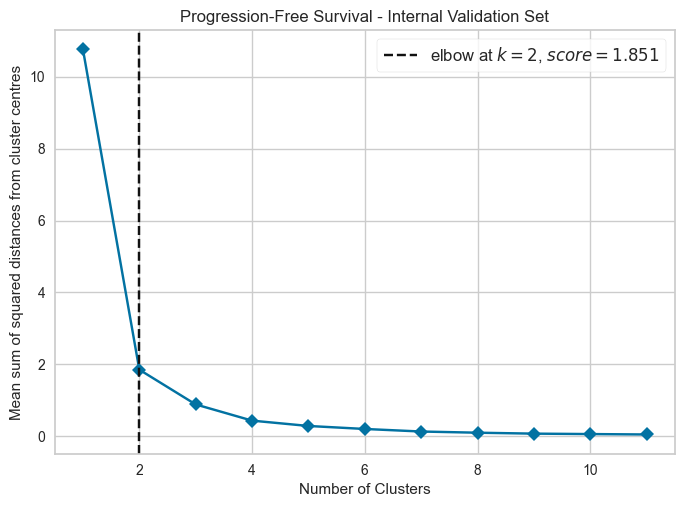

In [212]:
# Using unsupervised machine learning to stratify risk groups and compare median OS

# Determine optimal cluster number using elbow plot

from sklearn.cluster import KMeans
from src.model_evaluation.survival_metrics import km_curve_at_risk

X_train_clinical_km = X_train_mod.join(df_2[["DEAD","OS (months)"]])
X_train_clinical_km["Ensemble_proba"]=ensemble_model_results["ensemble_model"]["train_proba"][0]

X_val_clinical_km = X_val_mod.join(df_2[["DEAD","OS (months)"]])
X_val_clinical_km["Ensemble_proba"]=ensemble_model_results["ensemble_model"]["test_proba"][0]

X_test_clinical_km = X_test.join(df_2[["DEAD","OS (months)"]])
X_test_clinical_km["Ensemble_proba"]=ensemble_model_results["ensemble_model"]["new_test_proba"]

# elbow plot from YellowBrick Module

from yellowbrick.cluster import KElbowVisualizer

visualizer = KElbowVisualizer(KMeans(), k=(1,12), timings=False)

visualizer.fit(X_val_clinical_km[["Ensemble_proba"]])
visualizer.finalize()
visualizer.ax.set_xlabel("Number of Clusters")
visualizer.ax.set_ylabel("Mean sum of squared distances from cluster centres")
visualizer.ax.set_title("Progression-Free Survival - Internal Validation Set")

e:\Box\One Drive To Box Migration\Immunotherapy_databases\Italy\ML\git_project\.venv\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
e:\Box\One Drive To Box Migration\Immunotherapy_databases\Italy\ML\git_project\.venv\lib\site-packages\lifelines\fitters\kaplan_meier_fitter.py:444: DeprecationWarning: The `plot` function is deprecated, and will be removed in future versions. Use `plot_survival_function`
  warnings.warn(
e:\Box\One Drive To Box Migration\Immunotherapy_databases\Italy\ML\git_project\.venv\lib\site-packages\lifelines\fitters\kaplan_meier_fitter.py:444: DeprecationWarning: The `plot` function is deprecated, and will be removed in future versions. Use `plot_survival_function`
  warnings.warn(
e:\Box\One Drive To Box Migration\Immunotherapy_databases\Italy\ML\git_project\.venv\

   Cluster  Median OS  Lower CI  Upper CI
0      0.0       16.1      14.1      20.0
1      1.0        6.7       3.5      10.9

Cluster 0 vs Cluster 1
   test_statistic         p  -log2(p)
0        6.594876  0.010227  6.611435

Multiple log rank
   test_statistic         p   -log2(p)
0        14.69638  0.000126  12.950986
   Cluster  Median OS  Lower CI  Upper CI
0      0.0       16.4      14.2      21.6
1      1.0        5.0       3.0       6.9

Cluster 0 vs Cluster 1
   test_statistic         p   -log2(p)
0       19.325322  0.000011  16.469062

Multiple log rank
   test_statistic             p   -log2(p)
0       43.479244  4.284801e-11  34.441981


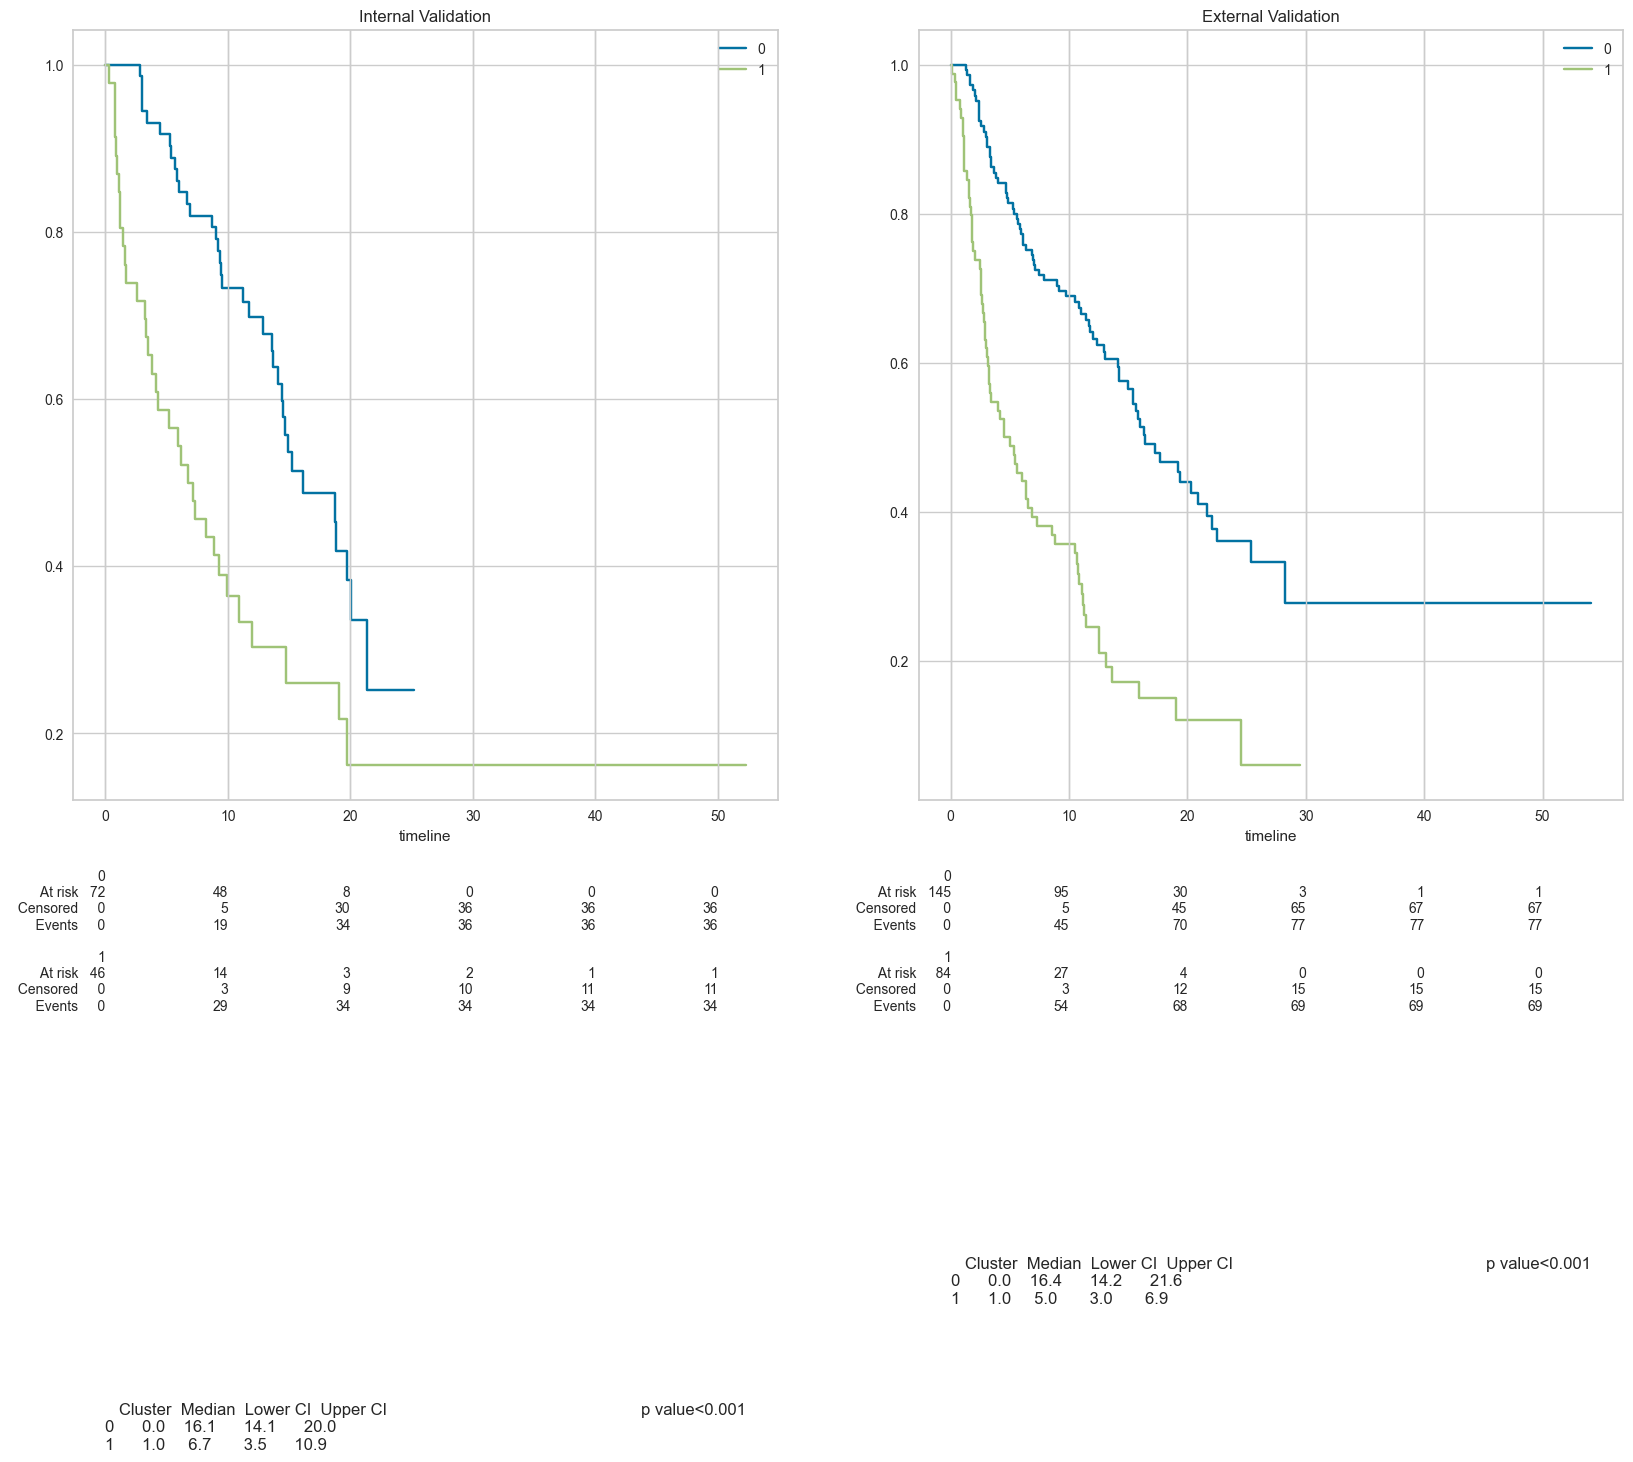

In [ ]:
# Using unsupervised machine learning to stratify risk groups and compare median OS 

from sklearn.cluster import KMeans
from src.model_evaluation.survival_metrics import km_curve_at_risk

X_train_clinical_km = X_train_mod.join(df_2[["DEAD","OS (months)"]])
X_train_clinical_km["Ensemble_proba"]=ensemble_model_results["ensemble_model"]["train_proba"][0]

X_val_clinical_km = X_val_mod.join(df_2[["DEAD","OS (months)"]])
X_val_clinical_km["Ensemble_proba"]=ensemble_model_results["ensemble_model"]["test_proba"][0]

X_test_clinical_km = X_test.join(df_2[["DEAD","OS (months)"]])
X_test_clinical_km["Ensemble_proba"]=ensemble_model_results["ensemble_model"]["new_test_proba"]

# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_val_clinical_km[["Ensemble_proba"]])

X_train_clinical_km["cluster"] = model.predict(X_train_clinical_km[["Ensemble_proba"]])
X_val_clinical_km["cluster"] = model.predict(X_val_clinical_km[["Ensemble_proba"]])
X_test_clinical_km["cluster"] = model.predict(X_test_clinical_km[["Ensemble_proba"]])

fig = plt.figure(figsize=(20, 10))

# Survival Curve - OS from internal validation set

ax1=fig.add_subplot(1,2,1)
km_curve_at_risk(X_val_clinical_km["DEAD"], X_val_clinical_km["OS (months)"], X_val_clinical_km["cluster"], "Internal Validation", ax=ax1)

ax2=fig.add_subplot(1,2,2)
km_curve_at_risk(X_test_clinical_km["DEAD"], X_test_clinical_km["OS (months)"], X_test_clinical_km["cluster"], "External Validation", ax=ax2)

plt.subplots_adjust(hspace=0.8, wspace=0.2)

e:\Box\One Drive To Box Migration\Immunotherapy_databases\Italy\ML\git_project\.venv\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\mat2k\AppData\Local\Temp\ipykernel_6208\4271220475.py:42: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate(f"Threshold: {threshold[0]:.2f}", (0.5,threshold[0]), textcoords="offset points", va='bottom', ha="center")
C:\Users\mat2k\AppData\Local\Temp\ipykernel_6208\4271220475.py:45: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate("Low-Risk", (1.1,test_centroids[0]), textcoords="offset points")
C:\Users\mat2k\AppData\Local\Temp\ipykernel_6208\4271220475.py:46: UserWarning: You have used 

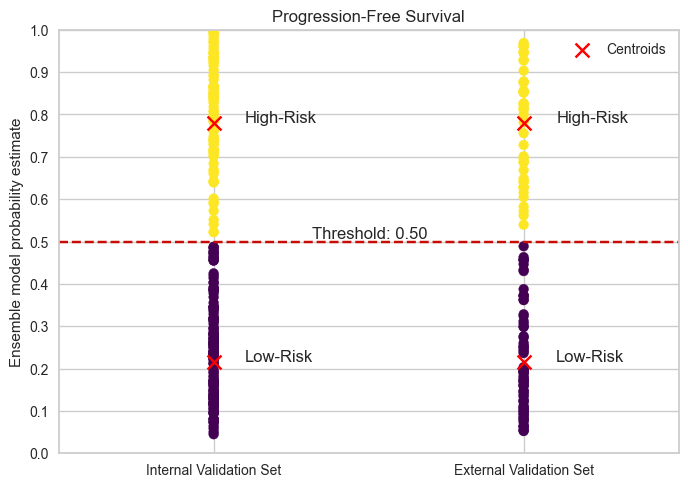

In [214]:
# Plot clusters in 1-D dot plot

import matplotlib.pyplot as plt
import numpy as np

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_val_clinical_km[["Ensemble_proba"]])

X_val_clinical_km["cluster"] = model.predict(X_val_clinical_km[["Ensemble_proba"]])

val_labels = X_val_clinical_km["cluster"]
val_centroids = model.cluster_centers_

X_test_clinical_km["cluster"] = model.predict(X_test_clinical_km[["Ensemble_proba"]])

test_labels = X_test_clinical_km["cluster"]
test_centroids = model.cluster_centers_

# Sort centroids for calculating midpoints as thresholds
sorted_centroids = np.sort(val_centroids, axis=0)

# Plot val data points
plt.scatter(y=X_val_clinical_km[["Ensemble_proba"]], x=1+(np.zeros_like(X_val_clinical_km[["Ensemble_proba"]])), c=val_labels, cmap='viridis')

# Plot val centroids
plt.scatter(y=val_centroids, x=1+(np.zeros_like(val_centroids)), c='red', s=100, marker='x', label='Centroids')

# Plot test data points
plt.scatter(y=X_test_clinical_km[["Ensemble_proba"]], x=np.zeros_like(X_test_clinical_km[["Ensemble_proba"]]), c=test_labels, cmap='viridis')

# Plot test centroids
plt.scatter(y=test_centroids, x=(np.zeros_like(test_centroids)), c='red', s=100, marker='x')

# Calculate and plot thresholds (midpoints between centroids) and write threshold line value
thresholds = (sorted_centroids[:-1] + sorted_centroids[1:]) / 2
for threshold in thresholds:
    plt.axhline(y=threshold, color='r', linestyle='--')

# label threshold line with value with offset to the right of line
for i, threshold in enumerate(thresholds):
    plt.annotate(f"Threshold: {threshold[0]:.2f}", (0.5,threshold[0]), textcoords="offset points", va='bottom', ha="center")

# add label to each centroid
plt.annotate("Low-Risk", (1.1,test_centroids[0]), textcoords="offset points")
plt.annotate("High-Risk", (1.1,test_centroids[1]), textcoords="offset points")
plt.annotate("Low-Risk", (0.1,val_centroids[0]), textcoords="offset points")
plt.annotate("High-Risk", (0.1,val_centroids[1]), textcoords="offset points")

plt.ylabel('Ensemble model probability estimate')
plt.yticks([])
plt.title('Progression-Free Survival')

# Set X-axis ticks from 0 to 1
plt.xticks([0,1], ["Internal Validation Set","External Validation Set"])

# Set X-axis range from 0 to 1
plt.xlim(-0.5, 1.5)

# Set Y-axis range from 0 to 1
plt.ylim(0, 1)

# Set X-axis ticks from 0 to 1 with 0.1 increments
plt.yticks(np.arange(0, 1.1, 0.1))

plt.legend()
plt.show()

e:\Box\One Drive To Box Migration\Immunotherapy_databases\Italy\ML\git_project\.venv\lib\site-packages\lifelines\fitters\kaplan_meier_fitter.py:444: DeprecationWarning: The `plot` function is deprecated, and will be removed in future versions. Use `plot_survival_function`
  warnings.warn(
e:\Box\One Drive To Box Migration\Immunotherapy_databases\Italy\ML\git_project\.venv\lib\site-packages\lifelines\fitters\kaplan_meier_fitter.py:444: DeprecationWarning: The `plot` function is deprecated, and will be removed in future versions. Use `plot_survival_function`
  warnings.warn(
e:\Box\One Drive To Box Migration\Immunotherapy_databases\Italy\ML\git_project\.venv\lib\site-packages\lifelines\fitters\kaplan_meier_fitter.py:444: DeprecationWarning: The `plot` function is deprecated, and will be removed in future versions. Use `plot_survival_function`
  warnings.warn(
e:\Box\One Drive To Box Migration\Immunotherapy_databases\Italy\ML\git_project\.venv\lib\site-packages\lifelines\fitters\kaplan_me

   Cluster  Median OS  Lower CI  Upper CI
0      0.0       18.8      14.5      21.4
1      1.0        8.2       4.4      10.9

Cluster 0 vs Cluster 1
   test_statistic         p  -log2(p)
0        7.643464  0.005698  7.455369

Multiple log rank
   test_statistic         p   -log2(p)
0       14.700614  0.000126  12.954227
   Cluster  Median OS  Lower CI  Upper CI
0      0.0       20.3      15.4      25.4
1      1.0        5.7       4.0       7.9

Cluster 0 vs Cluster 1
   test_statistic         p   -log2(p)
0       21.181727  0.000004  17.869004

Multiple log rank
   test_statistic             p   -log2(p)
0       38.826769  4.631330e-10  31.007854


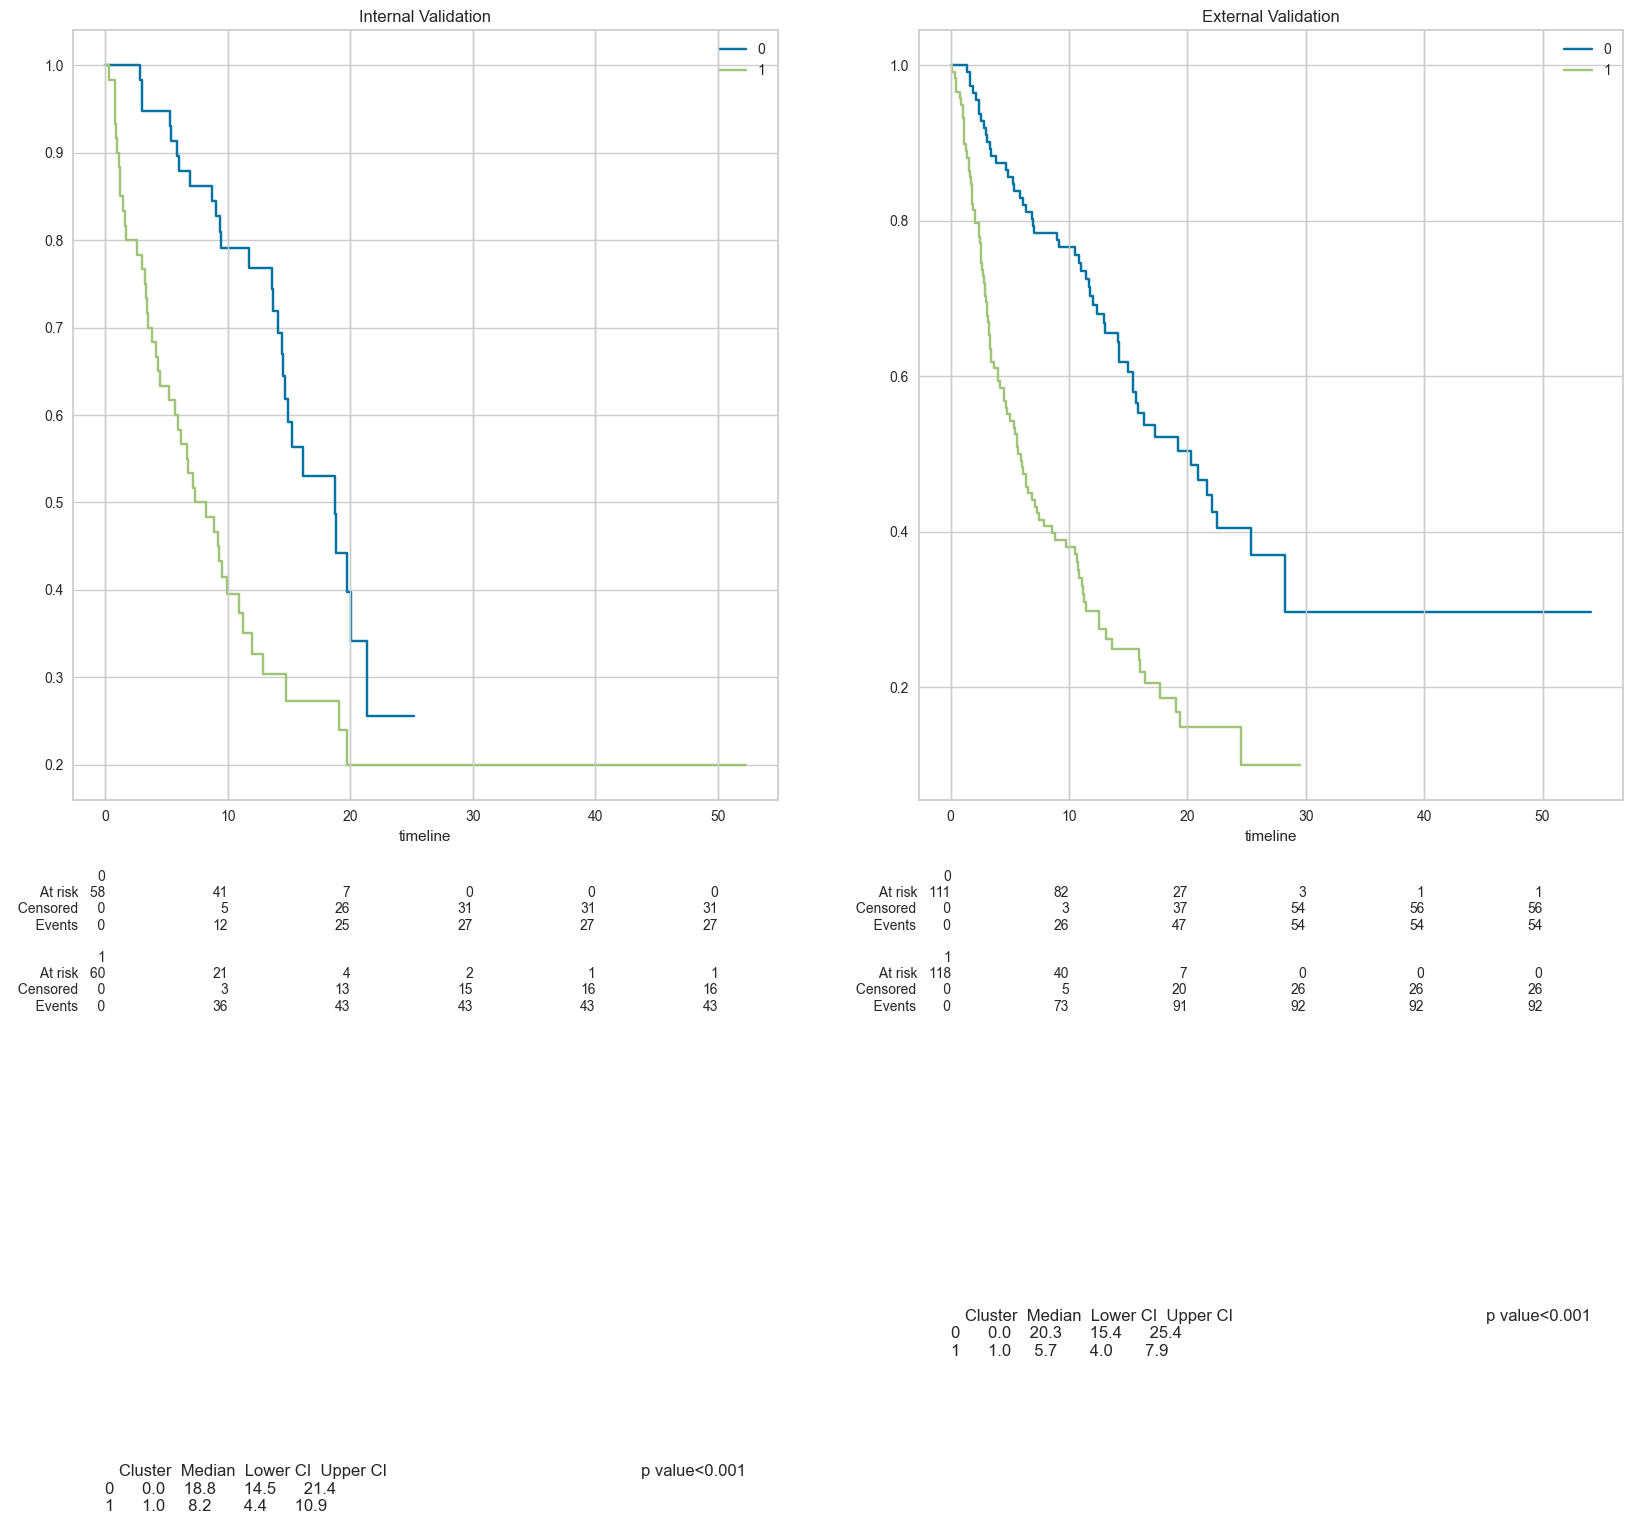

In [215]:
# Youden index survival cut-off

# ensemble survival curve using youden index cut-off for top 3 models

from sklearn.cluster import KMeans
from src.model_evaluation.survival_metrics import km_curve_at_risk
from src.model_evaluation.model_metrics import sensivity_specifity_cutoff

youden_index = sensivity_specifity_cutoff(ensemble_model_results["ensemble_model"]["test_truth"][0], ensemble_model_results["ensemble_model"]["test_proba"][0])

X_train_clinical_km["Ensemble_label"]=ensemble_model_results["ensemble_model"]["train_proba"][0] > youden_index 
X_train_clinical_km["Ensemble_label"] = X_train_clinical_km["Ensemble_label"].astype(int)

X_val_clinical_km["Ensemble_label"]=ensemble_model_results["ensemble_model"]["test_proba"][0] > youden_index
X_val_clinical_km["Ensemble_label"] = X_val_clinical_km["Ensemble_label"].astype(int)

X_test_clinical_km["Ensemble_label"]=ensemble_model_results["ensemble_model"]["new_test_proba"] > youden_index
X_test_clinical_km["Ensemble_label"] = X_test_clinical_km["Ensemble_label"].astype(int)


fig = plt.figure(figsize=(20, 10))

# Survival Curves

ax1=fig.add_subplot(1,2,1)
km_curve_at_risk(X_val_clinical_km["DEAD"], X_val_clinical_km["OS (months)"], X_val_clinical_km["Ensemble_label"], "Internal Validation", ax=ax1)

ax2=fig.add_subplot(1,2,2)
km_curve_at_risk(X_test_clinical_km["DEAD"], X_test_clinical_km["OS (months)"], X_test_clinical_km["Ensemble_label"], "External Validation", ax=ax2)

plt.subplots_adjust(hspace=0.8, wspace=0.2)

In [216]:
# Overall response rate by cohort

from src.model_evaluation.model_metrics import roc_curve

# Response assessment by model cluster

df_missing["Best Response (RECIST)"].value_counts()

X_train_clinical_km["Best Response (RECIST)"]=df_missing["Best Response (RECIST)"]
X_val_clinical_km["Best Response (RECIST)"]=df_missing["Best Response (RECIST)"]
X_test_clinical_km["Best Response (RECIST)"]=df_missing["Best Response (RECIST)"]

X_train_clinical_km["Response"] = np.nan
X_train_clinical_km["Response"] = np.where(X_train_clinical_km["Best Response (RECIST)"]==1,1,X_train_clinical_km["Response"] )
X_train_clinical_km["Response"] = np.where(X_train_clinical_km["Best Response (RECIST)"]==2,1,X_train_clinical_km["Response"] )
X_train_clinical_km["Response"] = np.where(X_train_clinical_km["Best Response (RECIST)"]==3,0,X_train_clinical_km["Response"] )
X_train_clinical_km["Response"] = np.where(X_train_clinical_km["Best Response (RECIST)"]==4,0,X_train_clinical_km["Response"] )

X_train_clinical_km["Response"].value_counts()

X_val_clinical_km["Response"] = np.nan
X_val_clinical_km["Response"] = np.where(X_val_clinical_km["Best Response (RECIST)"]==1,1,X_val_clinical_km["Response"] )
X_val_clinical_km["Response"] = np.where(X_val_clinical_km["Best Response (RECIST)"]==2,1,X_val_clinical_km["Response"] )
X_val_clinical_km["Response"] = np.where(X_val_clinical_km["Best Response (RECIST)"]==3,0,X_val_clinical_km["Response"] )
X_val_clinical_km["Response"] = np.where(X_val_clinical_km["Best Response (RECIST)"]==4,0,X_val_clinical_km["Response"] )

X_val_clinical_km["Response"].value_counts()

X_test_clinical_km["Response"] = np.nan
X_test_clinical_km["Response"] = np.where(X_test_clinical_km["Best Response (RECIST)"]==1,1,X_test_clinical_km["Response"] )
X_test_clinical_km["Response"] = np.where(X_test_clinical_km["Best Response (RECIST)"]==2,1,X_test_clinical_km["Response"] )
X_test_clinical_km["Response"] = np.where(X_test_clinical_km["Best Response (RECIST)"]==3,0,X_test_clinical_km["Response"] )
X_test_clinical_km["Response"] = np.where(X_test_clinical_km["Best Response (RECIST)"]==4,0,X_test_clinical_km["Response"] )

X_test_clinical_km["Response"].value_counts()

# AUC for response assessment

# Calculate the ROC curves
fpr_train, tpr_train, _ = roc_curve(X_train_clinical_km["Response"][X_train_clinical_km["Response"].notna()], X_train_clinical_km["Ensemble_proba"][X_train_clinical_km["Response"].notna()])
fpr_val, tpr_val, _ = roc_curve(X_val_clinical_km["Response"][X_val_clinical_km["Response"].notna()], X_val_clinical_km["Ensemble_proba"][X_val_clinical_km["Response"].notna()])
fpr_test, tpr_test, _ = roc_curve(X_test_clinical_km["Response"][X_test_clinical_km["Response"].notna()], X_test_clinical_km["Ensemble_proba"][X_test_clinical_km["Response"].notna()])

# Get AUC values
auc_train = compute_auc_ci(X_train_clinical_km["Response"][X_train_clinical_km["Response"].notna()], X_train_clinical_km["Ensemble_proba"][X_train_clinical_km["Response"].notna()])
auc_val = compute_auc_ci(X_val_clinical_km["Response"][X_val_clinical_km["Response"].notna()], X_val_clinical_km["Ensemble_proba"][X_val_clinical_km["Response"].notna()])
auc_test = compute_auc_ci(X_test_clinical_km["Response"][X_test_clinical_km["Response"].notna()], X_test_clinical_km["Ensemble_proba"][X_test_clinical_km["Response"].notna()])

print("Ensemble top 3 model AUC")
print(auc_train)
print(auc_val)
print(auc_test)

# Calculate chi-squared p value for response assessment for ensemble model - Test
from scipy.stats import chi2_contingency

res = chi2_contingency(pd.crosstab(X_test_clinical_km["Response"][X_test_clinical_km["Response"].notna()], X_test_clinical_km["cluster"][X_test_clinical_km["Response"].notna()]))

print("\nTest ORR and p value")
print(pd.crosstab(X_test_clinical_km["Response"][X_test_clinical_km["Response"].notna()], X_test_clinical_km["cluster"][X_test_clinical_km["Response"].notna()],margins=True))
print("")
print(pd.crosstab(X_test_clinical_km["Response"][X_test_clinical_km["Response"].notna()], X_test_clinical_km["cluster"][X_test_clinical_km["Response"].notna()], normalize="columns", margins=True))
print(res.pvalue)


# Calculate chi-squared p value for response assessment for ensemble model - Validation
from scipy.stats import chi2_contingency

res = chi2_contingency(pd.crosstab(X_val_clinical_km["Response"][X_val_clinical_km["Response"].notna()], X_val_clinical_km["cluster"][X_val_clinical_km["Response"].notna()]))

print("\nValidation ORR and p value")
print(pd.crosstab(X_val_clinical_km["Response"][X_val_clinical_km["Response"].notna()], X_val_clinical_km["cluster"][X_val_clinical_km["Response"].notna()], margins=True))
print("")
print(pd.crosstab(X_val_clinical_km["Response"][X_val_clinical_km["Response"].notna()], X_val_clinical_km["cluster"][X_val_clinical_km["Response"].notna()], normalize="columns", margins=True))
print(res.pvalue)


# Calculate chi-squared p value for response assessment for ensemble model - Training
from scipy.stats import chi2_contingency

res = chi2_contingency(pd.crosstab(X_train_clinical_km["Response"][X_train_clinical_km["Response"].notna()], X_train_clinical_km["cluster"][X_train_clinical_km["Response"].notna()]))

print("\nTraining ORR and p value")
print(pd.crosstab(X_train_clinical_km["Response"][X_train_clinical_km["Response"].notna()], X_train_clinical_km["cluster"][X_train_clinical_km["Response"].notna()], margins=True))
print("")
print(pd.crosstab(X_train_clinical_km["Response"][X_train_clinical_km["Response"].notna()], X_train_clinical_km["cluster"][X_train_clinical_km["Response"].notna()], normalize="columns", margins=True))
print(res.pvalue)


Ensemble top 3 model AUC
(0.35293690026170393, 0.2843391902215432, 0.4260686246001744)
(0.4222035323801514, 0.30268199233716475, 0.5444664031620553)
(0.3484768907563025, 0.26840659340659345, 0.43014128728414447)

Test ORR and p value
cluster     0   1  All
Response              
0.0        85  51  136
1.0        44  12   56
All       129  63  192

cluster          0         1       All
Response                              
0.0       0.658915  0.809524  0.708333
1.0       0.341085  0.190476  0.291667
0.04695624801419304

Validation ORR and p value
cluster    0   1  All
Response             
0.0       49  33   82
1.0       20   9   29
All       69  42  111

cluster          0         1       All
Response                              
0.0       0.710145  0.785714  0.738739
1.0       0.289855  0.214286  0.261261
0.5117072061033839

Training ORR and p value
cluster     0   1  All
Response              
0.0       110  71  181
1.0        61  15   76
All       171  86  257

cluster          0

In [218]:
# Determine permutation feature importance for ensemble model in the test set

from sklearn.inspection import permutation_importance

# Model 1

results = permutation_importance(ensemble_model_results["model_1"]['new_model_predictor'], X_test_scale[baseline_selected_features_dict[ensemble_model_results["model_1"]["feature_set_name"]]], y_test, scoring='roc_auc', random_state=42, n_jobs=50)

feature_importance = results.importances_mean

feature_importance_df = pd.concat([pd.DataFrame(baseline_selected_features_dict[ensemble_model_results["model_1"]["feature_set_name"]], columns=["feature"]), pd.DataFrame(feature_importance, columns=["feature_importance"])],axis=1)

feature_importance_df["feature_importance_mag"]=abs(feature_importance_df["feature_importance"])

feature_importance_df.sort_values(["feature_importance_mag"], ascending=False, inplace=True)

print(ensemble_model_results["model_1"]["model_name"], " + ", ensemble_model_results["model_1"]["feature_set_name"])
display(feature_importance_df)


# Model 2

results = permutation_importance(ensemble_model_results["model_2"]['new_model_predictor'], X_test_scale[baseline_selected_features_dict[ensemble_model_results["model_2"]["feature_set_name"]]], y_test, scoring='roc_auc', random_state=42, n_jobs=50)

feature_importance = results.importances_mean

feature_importance_df = pd.concat([pd.DataFrame(baseline_selected_features_dict[ensemble_model_results["model_2"]["feature_set_name"]], columns=["feature"]), pd.DataFrame(feature_importance, columns=["feature_importance"])],axis=1)

feature_importance_df["feature_importance_mag"]=abs(feature_importance_df["feature_importance"])

feature_importance_df.sort_values(["feature_importance_mag"], ascending=False, inplace=True)

print(ensemble_model_results["model_2"]["model_name"], " + ", ensemble_model_results["model_2"]["feature_set_name"])
display(feature_importance_df)


# Model 3

results = permutation_importance(ensemble_model_results["model_3"]['new_model_predictor'], X_test_scale[baseline_selected_features_dict[ensemble_model_results["model_3"]["feature_set_name"]]], y_test, scoring='roc_auc', random_state=42, n_jobs=50)

feature_importance = results.importances_mean

feature_importance_df = pd.concat([pd.DataFrame(baseline_selected_features_dict[ensemble_model_results["model_3"]["feature_set_name"]], columns=["feature"]), pd.DataFrame(feature_importance, columns=["feature_importance"])],axis=1)

feature_importance_df["feature_importance_mag"]=abs(feature_importance_df["feature_importance"])

feature_importance_df.sort_values(["feature_importance_mag"], ascending=False, inplace=True)

print(ensemble_model_results["model_3"]["model_name"], " + ", ensemble_model_results["model_3"]["feature_set_name"])
display(feature_importance_df)

Support Vector Machine  +  Kendall


,feature,feature_importance,feature_importance_mag
0,PVT 01,0.043973,0.043973
5,AFP,0.035139,0.035139
4,Bilirubin,0.032591,0.032591
1,Alb g/l,0.015380,0.015380
2,ALP,0.013396,0.013396
12,Sodium (Na+) mmol/L,0.013030,0.013030
16,Sex,-0.011230,0.011230
13,Hb g/dL,0.004272,0.004272
10,Previous_surgery,0.002624,0.002624
3,Child-Pugh Class_1.0,0.002533,0.002533


Neural Network  +  RFE


,feature,feature_importance,feature_importance_mag
6,Alb g/l,0.046186,0.046186
2,AFP,0.043607,0.043607
7,Bilirubin,0.034986,0.034986
10,Neuts,0.015471,0.015471
20,PVT 01,0.010787,0.010787
5,ALP,0.010726,0.010726
0,Age at Atezo/BevStart,-0.010345,0.010345
12,PLT,0.010223,0.010223
35,Number of nodules_1.0,0.008499,0.008499
27,Previous_surgery,0.007110,0.007110


Naive Bayes  +  Pearson


,feature,feature_importance,feature_importance_mag
3,Child-Pugh Class_1.0,0.043271,0.043271
4,AFP,0.041623,0.041623
2,Bilirubin,0.023360,0.023360
0,PVT 01,0.012557,0.012557
7,ALP,0.010673,0.010673
1,Alb g/l,0.008941,0.008941
13,Previous_surgery,0.008499,0.008499
6,BCLC STAGE_2.0,0.007858,0.007858
8,MTD(cm),0.006164,0.006164
12,Sodium (Na+) mmol/L,-0.004074,0.004074
